# TextCNN AG News Embedding Experiments

**Saman Zobeiry**  
**26 April 2026**

**Model:** TextCNN  
**Dataset:** AG News  
**Experiment:** Random, GloVe, and FastText embeddings across different training data sizes

This notebook tests how a TextCNN classifier performs on AG News when the amount of labelled training data is reduced. Three embedding settings are compared: randomly initialised embeddings, GloVe embeddings, and FastText embeddings. A fixed validation split is used, and all final results are evaluated on the official AG News test set.

In [ ]:
!pip install -q datasets wandb

In [ ]:
import os
import time

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wandb

from datasets import load_dataset
from collections import Counter
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Use GPU if Colab gives one
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# W&B is optional. Keep it off for a clean notebook run.
# Set this to True only if you want to log the run to your W&B account.
WANDB_ENABLED = False

if WANDB_ENABLED:
    wandb.init(
        project="textcnn-agnews-data-size",
        name="textcnn_embeddings_data_size",
        config={
            "model": "TextCNN",
            "dataset": "AG News",
            "device": str(device)
        }
    )
else:
    os.environ["WANDB_MODE"] = "disabled"
    print("W&B logging disabled")

Using device: cuda
W&B logging disabled


In [ ]:
# Load AG News dataset
dataset = load_dataset("ag_news")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [ ]:
# Quick check of the text and label format
print(dataset["train"][0])
print(dataset["train"][1])
print(dataset["train"][2])

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}
{'text': 'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\\which has a reputation for making well-timed and occasionally\\controversial plays in the defense industry, has quietly placed\\its bets on another part of the market.', 'label': 2}
{'text': "Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\\about the economy and the outlook for earnings are expected to\\hang over the stock market next week during the depth of the\\summer doldrums.", 'label': 2}


In [ ]:
# Check class balance in the training set
labels = [x["label"] for x in dataset["train"]]

print(Counter(labels))

Counter({2: 30000, 3: 30000, 1: 30000, 0: 30000})


In [ ]:
# Label index mapping used by AG News
print(dataset["train"].features["label"].names)

['World', 'Sports', 'Business', 'Sci/Tech']


In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Extract raw text and labels from AG News
train_texts = [example["text"] for example in dataset["train"]]
train_labels = [example["label"] for example in dataset["train"]]

test_texts = [example["text"] for example in dataset["test"]]
test_labels = [example["label"] for example in dataset["test"]]

# Class names are used later for reports and confusion matrices
class_names = dataset["train"].features["label"].names

print(f"Training articles: {len(train_texts)}")
print(f"Test articles: {len(test_texts)}")
print(f"Classes: {class_names}")

Training articles: 120000
Test articles: 7600
Classes: ['World', 'Sports', 'Business', 'Sci/Tech']


In [ ]:
from sklearn.model_selection import train_test_split

# Main preprocessing settings
MAX_LEN = 50
VOCAB_SIZE = 20000
SEED = 42
VAL_SIZE = 0.05

# Keep one fixed validation split for all data-size runs.
# This makes the validation protocol closer to the RoBERTa and BiLSTM notebooks.
train_pool_texts, val_texts, train_pool_labels, val_labels = train_test_split(
    train_texts,
    train_labels,
    test_size=VAL_SIZE,
    stratify=train_labels,
    random_state=SEED
)

print("Training pool articles:", len(train_pool_texts))
print("Validation articles:", len(val_texts))
print("Test articles:", len(test_texts))


# Basic whitespace tokeniser used for the TextCNN baseline
def tokenize(text):
    return text.lower().split()


# Make a smaller training set while keeping the class balance
def create_subset(texts, labels, fraction, seed=SEED):
    if fraction == 1.0:
        return texts, labels

    subset_texts, _, subset_labels, _ = train_test_split(
        texts,
        labels,
        train_size=fraction,
        stratify=labels,
        random_state=seed
    )

    return subset_texts, subset_labels


# Build the vocabulary from the current training subset only.
# The validation and test sets are not used to build the vocab.
def build_vocab(texts):
    all_words = []

    for text in texts:
        all_words.extend(tokenize(text))

    word_counts = Counter(all_words)

    # The final vocabulary has PAD + UNK + the most common training words.
    vocab = ["<PAD>", "<UNK>"] + [
        word for word, count in word_counts.most_common(VOCAB_SIZE)
    ]

    word2idx = {word: idx for idx, word in enumerate(vocab)}

    return vocab, word2idx


# Convert one article to fixed-length word indexes
def text_to_sequence(text, word2idx):
    tokens = tokenize(text)
    seq = [word2idx.get(word, 1) for word in tokens]  # 1 is <UNK>

    if len(seq) < MAX_LEN:
        seq = seq + [0] * (MAX_LEN - len(seq))        # 0 is <PAD>
    else:
        seq = seq[:MAX_LEN]

    return seq


# Prepare tensors for one run.
# Training data changes by fraction, but validation and test stay fixed.
def prepare_data(train_texts_subset, train_labels_subset, test_texts, test_labels):
    vocab, word2idx = build_vocab(train_texts_subset)

    train_seqs = [text_to_sequence(text, word2idx) for text in train_texts_subset]
    val_seqs = [text_to_sequence(text, word2idx) for text in val_texts]
    test_seqs = [text_to_sequence(text, word2idx) for text in test_texts]

    X_train = torch.tensor(train_seqs, dtype=torch.long)
    y_train = torch.tensor(train_labels_subset, dtype=torch.long)

    X_val = torch.tensor(val_seqs, dtype=torch.long)
    y_val = torch.tensor(val_labels, dtype=torch.long)

    X_test = torch.tensor(test_seqs, dtype=torch.long)
    y_test = torch.tensor(test_labels, dtype=torch.long)

    return X_train, y_train, X_val, y_val, X_test, y_test, vocab, word2idx


# Data fractions used in the data-size experiment
fractions = {
    "1%": 0.01,
    "5%": 0.05,
    "10%": 0.10,
    "25%": 0.25,
    "50%": 0.50,
    "100%": 1.00
}

Training pool articles: 114000
Validation articles: 6000
Test articles: 7600


In [ ]:
# Average input token statistics

train_pool_token_lengths = [len(tokenize(text)) for text in train_pool_texts]
val_token_lengths = [len(tokenize(text)) for text in val_texts]
test_token_lengths = [len(tokenize(text)) for text in test_texts]

avg_train_pool_tokens = np.mean(train_pool_token_lengths)
avg_val_tokens = np.mean(val_token_lengths)
avg_test_tokens = np.mean(test_token_lengths)

print(f"Average training-pool article length: {avg_train_pool_tokens:.2f} tokens")
print(f"Average validation article length: {avg_val_tokens:.2f} tokens")
print(f"Average test article length: {avg_test_tokens:.2f} tokens")
print(f"Fixed TextCNN input length: {MAX_LEN} tokens")

Average training-pool article length: 37.85 tokens
Average validation article length: 37.79 tokens
Average test article length: 37.72 tokens
Fixed TextCNN input length: 50 tokens


In [ ]:
# Quick check that preprocessing works

sample_texts, _, sample_labels, _ = train_test_split(
    train_pool_texts,
    train_pool_labels,
    train_size=1000,
    stratify=train_pool_labels,
    random_state=SEED
)

X_train_sample, y_train_sample, X_val_sample, y_val_sample, X_test_sample, y_test_sample, vocab, word2idx = prepare_data(
    sample_texts,
    sample_labels,
    test_texts,
    test_labels
)

print("Sample X_train shape:", X_train_sample.shape)
print("Sample X_val shape:", X_val_sample.shape)
print("Sample X_test shape:", X_test_sample.shape)
print("Vocabulary size:", len(vocab))

Sample X_train shape: torch.Size([1000, 50])
Sample X_val shape: torch.Size([6000, 50])
Sample X_test shape: torch.Size([7600, 50])
Vocabulary size: 10079


In [ ]:
# Create subsets for the data-size experiment
subsets = {}

for name, fraction in fractions.items():
    subset_texts, subset_labels = create_subset(
        train_pool_texts,
        train_pool_labels,
        fraction
    )

    subsets[name] = (subset_texts, subset_labels)
    print(f"{name} subset - {len(subset_texts)} articles")

1% subset - 1140 articles
5% subset - 5700 articles
10% subset - 11400 articles
25% subset - 28500 articles
50% subset - 57000 articles
100% subset - 114000 articles


In [ ]:
# Check that each subset still contains raw text before preprocessing
print(type(next(iter(subsets.values()))[0][0]))

<class 'str'>


In [ ]:
class TextCNN(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_classes,
        num_filters=100,
        filter_sizes=[3, 4, 5],
        dropout=0.5
    ):
        super(TextCNN, self).__init__()

        # Turns word indexes into dense vectors.
        # padding_idx=0 keeps the PAD token fixed.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Convolution filters scan over 3-, 4-, and 5-word windows.
        self.convs = nn.ModuleList([
            nn.Conv2d(1, num_filters, (fs, embed_dim))
            for fs in filter_sizes
        ])

        self.dropout = nn.Dropout(dropout)

        # One pooled vector from each filter size is joined before classification.
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        x = self.embedding(x)
        # x: (batch, seq_len, embed_dim)

        x = x.unsqueeze(1)
        # x: (batch, 1, seq_len, embed_dim)

        pooled = []

        for conv in self.convs:
            c = torch.relu(conv(x)).squeeze(3)
            c = torch.max_pool1d(c, c.size(2)).squeeze(2)
            pooled.append(c)

        x = torch.cat(pooled, dim=1)
        x = self.dropout(x)

        return self.fc(x)

print("TextCNN architecture defined successfully")

TextCNN architecture defined successfully


In [ ]:
# Quick check that the model can process one batch
model_check = TextCNN(vocab_size=1000, embed_dim=100, num_classes=4)

dummy_input = torch.randint(0, 1000, (8, 50))
dummy_output = model_check(dummy_input)

print("Dummy output shape:", dummy_output.shape)

Dummy output shape: torch.Size([8, 4])


In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    # no weight updates during validation or test
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            output = model(X_batch)
            loss = criterion(output, y_batch)

            preds = output.argmax(dim=1).cpu().numpy()

            total_loss += loss.item()
            all_preds.extend(preds)
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    f1 = f1_score(all_labels, all_preds, average="macro")
    f1_per_class = f1_score(all_labels, all_preds, average=None)
    cm = confusion_matrix(all_labels, all_preds)

    return avg_loss, acc, f1, f1_per_class, cm


print("Training and evaluation functions ready")

Training and evaluation functions ready


In [ ]:
# Experiment settings

EMBED_DIM = 100
NUM_CLASSES = 4
EPOCHS = 5
BATCH_SIZE = 64

NUM_FILTERS = 100
FILTER_SIZES = [3, 4, 5]
CONFIDENCE_Z = 1.96


def count_textcnn_params(vocab_size):
    embedding_params = vocab_size * EMBED_DIM

    conv_params = sum(
        NUM_FILTERS * (filter_size * EMBED_DIM + 1)
        for filter_size in FILTER_SIZES
    )

    fc_params = (NUM_FILTERS * len(FILTER_SIZES) * NUM_CLASSES) + NUM_CLASSES

    return embedding_params + conv_params + fc_params


def accuracy_ci(acc, n, z=CONFIDENCE_Z):
    margin = z * np.sqrt(acc * (1 - acc) / n)
    return max(0, acc - margin), min(1, acc + margin)


def error_count(acc, n):
    return round((1 - acc) * n)


results = {}

print("=" * 50)
print("EXPERIMENT: Random Embeddings")
print("=" * 50)

for size_name, (subset_texts, subset_labels) in subsets.items():
    print(f"\nTraining on {size_name} data - {len(subset_texts)} articles")

    # Prepare train, validation and test tensors for this run
    X_train, y_train, X_val, y_val, X_test, y_test, vocab, word2idx = prepare_data(
        subset_texts,
        subset_labels,
        test_texts,
        test_labels
    )

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val, y_val),
        batch_size=BATCH_SIZE
    )

    test_loader = DataLoader(
        TensorDataset(X_test, y_test),
        batch_size=BATCH_SIZE
    )

    # New model for this data size
    torch.manual_seed(SEED)

    model = TextCNN(
        vocab_size=len(vocab),
        embed_dim=EMBED_DIM,
        num_classes=NUM_CLASSES
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    val_accuracies = []
    val_macro_f1s = []

    # Train and validate after each epoch
    train_start = time.time()

    for epoch in range(EPOCHS):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        val_macro_f1s.append(val_f1)

        print(
            f"  Epoch {epoch + 1}/{EPOCHS} - "
            f"Train Loss: {train_loss:.4f} - "
            f"Val Loss: {val_loss:.4f} - "
            f"Val Acc: {val_acc:.4f} - "
            f"Val Macro F1: {val_f1:.4f}"
        )

    train_time = time.time() - train_start

    # Final test pass
    test_start = time.time()

    test_loss, test_acc, test_f1, f1_per_class, cm = evaluate(
        model,
        test_loader,
        criterion
    )

    test_time = time.time() - test_start

    train_examples_used = len(X_train)
    val_examples_used = len(X_val)
    test_examples_used = len(X_test)

    ci_low, ci_high = accuracy_ci(test_acc, test_examples_used)
    errors = error_count(test_acc, test_examples_used)

    result = {
        "method": "random",
        "size": size_name,

        "test_accuracy": test_acc,
        "test_macro_f1": test_f1,
        "world_f1": f1_per_class[0],
        "sports_f1": f1_per_class[1],
        "business_f1": f1_per_class[2],
        "sci_tech_f1": f1_per_class[3],

        "error_count": errors,
        "accuracy_ci_low": ci_low,
        "accuracy_ci_high": ci_high,

        "final_train_loss": train_losses[-1],
        "best_val_loss": min(val_losses),
        "best_val_accuracy": max(val_accuracies),
        "best_val_macro_f1": max(val_macro_f1s),
        "test_loss": test_loss,

        "train_time": train_time,
        "time_per_epoch": train_time / EPOCHS,
        "approx_gpu_hours": train_time / 3600,
        "test_time": test_time,
        "inference_latency_per_example": test_time / test_examples_used,
        "test_throughput_examples_per_second": test_examples_used / test_time,

        "train_examples_total": len(subset_texts),
        "train_examples_used": train_examples_used,
        "val_examples_used": val_examples_used,
        "test_examples_used": test_examples_used,

        "avg_input_tokens": avg_train_pool_tokens,
        "max_input_tokens": MAX_LEN,
        "total_train_tokens_seen": train_examples_used * MAX_LEN * EPOCHS,
        "total_val_tokens_seen": val_examples_used * MAX_LEN * EPOCHS,
        "total_test_tokens": test_examples_used * MAX_LEN,

        "accuracy_per_1k_train_examples": test_acc / (train_examples_used / 1000),
        "accuracy_per_million_train_tokens": test_acc / ((train_examples_used * MAX_LEN * EPOCHS) / 1_000_000),

        "vocab_size": len(vocab),
        "total_parameters": count_textcnn_params(len(vocab)),

        "confusion_matrix": cm,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
        "val_macro_f1s": val_macro_f1s
    }

    results[f"random_{size_name}"] = result

    if WANDB_ENABLED:
        wandb.log({
            "method": "random",
            "data_size": size_name,
            "test_accuracy": test_acc,
            "test_macro_f1": test_f1,
            "train_time": train_time,
            "test_time": test_time
        })

    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Test Macro F1: {test_f1:.4f}")
    print(f"  95% Accuracy CI: [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"  Error count: {errors}")
    print(f"  World F1: {f1_per_class[0]:.4f}")
    print(f"  Sports F1: {f1_per_class[1]:.4f}")
    print(f"  Business F1: {f1_per_class[2]:.4f}")
    print(f"  Sci/Tech F1: {f1_per_class[3]:.4f}")
    print(f"  Training time: {train_time:.1f}s")
    print(f"  Test time: {test_time:.4f}s")
    print(f"  Latency/article: {test_time / test_examples_used:.8f}s")
    print(f"  Vocab size: {len(vocab)}")

EXPERIMENT: Random Embeddings

Training on 1% data - 1140 articles
  Epoch 1/5 - Train Loss: 1.5757 - Val Loss: 1.3318 - Val Acc: 0.3493 - Val Macro F1: 0.3072
  Epoch 2/5 - Train Loss: 1.2603 - Val Loss: 1.2761 - Val Acc: 0.4430 - Val Macro F1: 0.4303
  Epoch 3/5 - Train Loss: 1.1012 - Val Loss: 1.2695 - Val Acc: 0.3697 - Val Macro F1: 0.2762
  Epoch 4/5 - Train Loss: 0.9755 - Val Loss: 1.1884 - Val Acc: 0.5460 - Val Macro F1: 0.5444
  Epoch 5/5 - Train Loss: 0.8069 - Val Loss: 1.1590 - Val Acc: 0.5608 - Val Macro F1: 0.5377
  Test Accuracy: 0.5572
  Test Macro F1: 0.5329
  95% Accuracy CI: [0.5461, 0.5684]
  Error count: 3365
  World F1: 0.4076
  Sports F1: 0.6565
  Business F1: 0.5865
  Sci/Tech F1: 0.4811
  Training time: 5.9s
  Test time: 0.2871s
  Latency/article: 0.00003778s
  Vocab size: 10952

Training on 5% data - 5700 articles
  Epoch 1/5 - Train Loss: 1.4344 - Val Loss: 1.1637 - Val Acc: 0.4885 - Val Macro F1: 0.4621
  Epoch 2/5 - Train Loss: 1.0999 - Val Loss: 0.9694 - Val

In [ ]:
# Load GloVe word vectors

import urllib.request
import zipfile
import os

# Download GloVe if it is not already in the Colab folder
if not os.path.exists("glove.6B.100d.txt"):
    print("Downloading GloVe vectors...")

    urllib.request.urlretrieve(
        "https://nlp.stanford.edu/data/glove.6B.zip",
        "glove.6B.zip"
    )

    print("Extracting...")
    with zipfile.ZipFile("glove.6B.zip", "r") as f:
        f.extract("glove.6B.100d.txt")

    print("Done")
else:
    print("GloVe already downloaded")

# Read word vectors into a dictionary
print("Loading GloVe vectors...")

glove = {}

with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        parts = line.split()
        word = parts[0]
        vector = np.array(parts[1:], dtype=np.float32)
        glove[word] = vector

print(f"GloVe loaded: {len(glove)} words")

# Small check that common AG News words are covered
print(f"'profit' in GloVe: {'profit' in glove}")
print(f"'tournament' in GloVe: {'tournament' in glove}")
print(f"'world' in GloVe: {'world' in glove}")

Extracting...
Done
Loading GloVe vectors...
GloVe loaded: 400000 words
'profit' in GloVe: True
'tournament' in GloVe: True
'world' in GloVe: True


In [ ]:
# Build a GloVe embedding matrix for one vocabulary

def build_glove_matrix(vocab, word2idx, glove, embed_dim=100):
    # Random vectors are used for words not found in GloVe
    embedding_matrix = np.random.uniform(
        -0.1,
        0.1,
        (len(vocab), embed_dim)
    ).astype(np.float32)

    # PAD token stays as zeros
    embedding_matrix[0] = np.zeros(embed_dim)

    found = 0

    for word, idx in word2idx.items():
        if word in glove:
            embedding_matrix[idx] = glove[word]
            found += 1

    return embedding_matrix, found

In [ ]:
# GloVe embedding experiment

print("=" * 50)
print("EXPERIMENT: GloVe Embeddings")
print("=" * 50)

for size_name, (subset_texts, subset_labels) in subsets.items():
    print(f"\nTraining on {size_name} data - {len(subset_texts)} articles")

    # Prepare train, validation and test tensors for this run
    X_train, y_train, X_val, y_val, X_test, y_test, vocab, word2idx = prepare_data(
        subset_texts,
        subset_labels,
        test_texts,
        test_labels
    )

    # Build GloVe weights for this run's vocabulary
    embedding_matrix_glove, found = build_glove_matrix(
        vocab,
        word2idx,
        glove,
        EMBED_DIM
    )

    glove_tensor = torch.tensor(embedding_matrix_glove, dtype=torch.float32)

    print(f"  Vocab size: {len(vocab)}")
    print(f"  Words found in GloVe: {found}")
    print(f"  GloVe coverage: {found / len(vocab) * 100:.1f}%")

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val, y_val),
        batch_size=BATCH_SIZE
    )

    test_loader = DataLoader(
        TensorDataset(X_test, y_test),
        batch_size=BATCH_SIZE
    )

    # New model for this data size
    torch.manual_seed(SEED)

    model = TextCNN(
        vocab_size=len(vocab),
        embed_dim=EMBED_DIM,
        num_classes=NUM_CLASSES
    ).to(device)

    # Start from GloVe vectors instead of random embedding weights
    model.embedding.weight.data.copy_(glove_tensor.to(device))

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    val_accuracies = []
    val_macro_f1s = []

    # Train and validate after each epoch
    train_start = time.time()

    for epoch in range(EPOCHS):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        val_macro_f1s.append(val_f1)

        print(
            f"  Epoch {epoch + 1}/{EPOCHS} - "
            f"Train Loss: {train_loss:.4f} - "
            f"Val Loss: {val_loss:.4f} - "
            f"Val Acc: {val_acc:.4f} - "
            f"Val Macro F1: {val_f1:.4f}"
        )

    train_time = time.time() - train_start

    # Final test pass
    test_start = time.time()

    test_loss, test_acc, test_f1, f1_per_class, cm = evaluate(
        model,
        test_loader,
        criterion
    )

    test_time = time.time() - test_start

    train_examples_used = len(X_train)
    val_examples_used = len(X_val)
    test_examples_used = len(X_test)

    ci_low, ci_high = accuracy_ci(test_acc, test_examples_used)
    errors = error_count(test_acc, test_examples_used)

    result = {
        "method": "glove",
        "size": size_name,

        "test_accuracy": test_acc,
        "test_macro_f1": test_f1,
        "world_f1": f1_per_class[0],
        "sports_f1": f1_per_class[1],
        "business_f1": f1_per_class[2],
        "sci_tech_f1": f1_per_class[3],

        "error_count": errors,
        "accuracy_ci_low": ci_low,
        "accuracy_ci_high": ci_high,

        "final_train_loss": train_losses[-1],
        "best_val_loss": min(val_losses),
        "best_val_accuracy": max(val_accuracies),
        "best_val_macro_f1": max(val_macro_f1s),
        "test_loss": test_loss,

        "train_time": train_time,
        "time_per_epoch": train_time / EPOCHS,
        "approx_gpu_hours": train_time / 3600,
        "test_time": test_time,
        "inference_latency_per_example": test_time / test_examples_used,
        "test_throughput_examples_per_second": test_examples_used / test_time,

        "train_examples_total": len(subset_texts),
        "train_examples_used": train_examples_used,
        "val_examples_used": val_examples_used,
        "test_examples_used": test_examples_used,

        "avg_input_tokens": avg_train_pool_tokens,
        "max_input_tokens": MAX_LEN,
        "total_train_tokens_seen": train_examples_used * MAX_LEN * EPOCHS,
        "total_val_tokens_seen": val_examples_used * MAX_LEN * EPOCHS,
        "total_test_tokens": test_examples_used * MAX_LEN,

        "accuracy_per_1k_train_examples": test_acc / (train_examples_used / 1000),
        "accuracy_per_million_train_tokens": test_acc / ((train_examples_used * MAX_LEN * EPOCHS) / 1_000_000),

        "vocab_size": len(vocab),
        "glove_found": found,
        "glove_coverage": found / len(vocab) * 100,
        "total_parameters": count_textcnn_params(len(vocab)),

        "confusion_matrix": cm,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
        "val_macro_f1s": val_macro_f1s
    }

    results[f"glove_{size_name}"] = result

    if WANDB_ENABLED:
        wandb.log({
            "method": "glove",
            "data_size": size_name,
            "test_accuracy": test_acc,
            "test_macro_f1": test_f1,
            "train_time": train_time,
            "test_time": test_time
        })

    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Test Macro F1: {test_f1:.4f}")
    print(f"  95% Accuracy CI: [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"  Error count: {errors}")
    print(f"  World F1: {f1_per_class[0]:.4f}")
    print(f"  Sports F1: {f1_per_class[1]:.4f}")
    print(f"  Business F1: {f1_per_class[2]:.4f}")
    print(f"  Sci/Tech F1: {f1_per_class[3]:.4f}")
    print(f"  Training time: {train_time:.1f}s")
    print(f"  Test time: {test_time:.4f}s")
    print(f"  Latency/article: {test_time / test_examples_used:.8f}s")

EXPERIMENT: GloVe Embeddings

Training on 1% data - 1140 articles
  Vocab size: 10952
  Words found in GloVe: 7797
  GloVe coverage: 71.2%
  Epoch 1/5 - Train Loss: 1.1436 - Val Loss: 0.8551 - Val Acc: 0.8195 - Val Macro F1: 0.8169
  Epoch 2/5 - Train Loss: 0.6285 - Val Loss: 0.5673 - Val Acc: 0.8570 - Val Macro F1: 0.8565
  Epoch 3/5 - Train Loss: 0.3938 - Val Loss: 0.4720 - Val Acc: 0.8535 - Val Macro F1: 0.8526
  Epoch 4/5 - Train Loss: 0.3052 - Val Loss: 0.4291 - Val Acc: 0.8598 - Val Macro F1: 0.8589
  Epoch 5/5 - Train Loss: 0.2189 - Val Loss: 0.4100 - Val Acc: 0.8697 - Val Macro F1: 0.8695
  Test Accuracy: 0.8596
  Test Macro F1: 0.8596
  95% Accuracy CI: [0.8518, 0.8674]
  Error count: 1067
  World F1: 0.8666
  Sports F1: 0.9315
  Business F1: 0.8213
  Sci/Tech F1: 0.8190
  Training time: 4.6s
  Test time: 0.1873s
  Latency/article: 0.00002464s

Training on 5% data - 5700 articles
  Vocab size: 20002
  Words found in GloVe: 13634
  GloVe coverage: 68.2%
  Epoch 1/5 - Train Loss

In [ ]:
# Load FastText word vectors

!pip install -q gensim

import gensim.downloader as api

print("Loading FastText vectors...")

fasttext = api.load("fasttext-wiki-news-subwords-300")

print("FastText loaded")

# Small check that common AG News words are covered
print(f"'profit' in FastText: {'profit' in fasttext}")
print(f"'tournament' in FastText: {'tournament' in fasttext}")
print(f"'world' in FastText: {'world' in fasttext}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.2 MB/s eta 0:00:00
Loading FastText vectors...
[==================================================] 100.0% 958.5/958.4MB downloaded
FastText loaded
'profit' in FastText: True
'tournament' in FastText: True
'world' in FastText: True


In [ ]:
# Build a FastText embedding matrix for one vocabulary

def build_fasttext_matrix(vocab, word2idx, fasttext, embed_dim=100):
    # Random vectors are used for words not found in FastText
    embedding_matrix = np.random.uniform(
        -0.1,
        0.1,
        (len(vocab), embed_dim)
    ).astype(np.float32)

    # PAD token stays as zeros
    embedding_matrix[0] = np.zeros(embed_dim)

    found = 0

    for word, idx in word2idx.items():
        if word in fasttext:
            # FastText vectors are 300d; this notebook uses 100d embeddings.
            embedding_matrix[idx] = fasttext[word][:embed_dim]
            found += 1

    return embedding_matrix, found

In [ ]:
# FastText embedding experiment

print("=" * 50)
print("EXPERIMENT: FastText Embeddings")
print("=" * 50)

for size_name, (subset_texts, subset_labels) in subsets.items():
    print(f"\nTraining on {size_name} data - {len(subset_texts)} articles")

    # Prepare train, validation and test tensors for this run
    X_train, y_train, X_val, y_val, X_test, y_test, vocab, word2idx = prepare_data(
        subset_texts,
        subset_labels,
        test_texts,
        test_labels
    )

    # Build FastText weights for this run's vocabulary
    embedding_matrix_fasttext, found = build_fasttext_matrix(
        vocab,
        word2idx,
        fasttext,
        EMBED_DIM
    )

    fasttext_tensor = torch.tensor(embedding_matrix_fasttext, dtype=torch.float32)

    print(f"  Vocab size: {len(vocab)}")
    print(f"  Words found in FastText: {found}")
    print(f"  FastText coverage: {found / len(vocab) * 100:.1f}%")

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val, y_val),
        batch_size=BATCH_SIZE
    )

    test_loader = DataLoader(
        TensorDataset(X_test, y_test),
        batch_size=BATCH_SIZE
    )

    # New model for this data size
    torch.manual_seed(SEED)

    model = TextCNN(
        vocab_size=len(vocab),
        embed_dim=EMBED_DIM,
        num_classes=NUM_CLASSES
    ).to(device)

    # Start from FastText vectors instead of random embedding weights
    model.embedding.weight.data.copy_(fasttext_tensor.to(device))

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    val_accuracies = []
    val_macro_f1s = []

    # Train and validate after each epoch
    train_start = time.time()

    for epoch in range(EPOCHS):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        val_macro_f1s.append(val_f1)

        print(
            f"  Epoch {epoch + 1}/{EPOCHS} - "
            f"Train Loss: {train_loss:.4f} - "
            f"Val Loss: {val_loss:.4f} - "
            f"Val Acc: {val_acc:.4f} - "
            f"Val Macro F1: {val_f1:.4f}"
        )

    train_time = time.time() - train_start

    # Final test pass
    test_start = time.time()

    test_loss, test_acc, test_f1, f1_per_class, cm = evaluate(
        model,
        test_loader,
        criterion
    )

    test_time = time.time() - test_start

    train_examples_used = len(X_train)
    val_examples_used = len(X_val)
    test_examples_used = len(X_test)

    ci_low, ci_high = accuracy_ci(test_acc, test_examples_used)
    errors = error_count(test_acc, test_examples_used)

    result = {
        "method": "fasttext",
        "size": size_name,

        "test_accuracy": test_acc,
        "test_macro_f1": test_f1,
        "world_f1": f1_per_class[0],
        "sports_f1": f1_per_class[1],
        "business_f1": f1_per_class[2],
        "sci_tech_f1": f1_per_class[3],

        "error_count": errors,
        "accuracy_ci_low": ci_low,
        "accuracy_ci_high": ci_high,

        "final_train_loss": train_losses[-1],
        "best_val_loss": min(val_losses),
        "best_val_accuracy": max(val_accuracies),
        "best_val_macro_f1": max(val_macro_f1s),
        "test_loss": test_loss,

        "train_time": train_time,
        "time_per_epoch": train_time / EPOCHS,
        "approx_gpu_hours": train_time / 3600,
        "test_time": test_time,
        "inference_latency_per_example": test_time / test_examples_used,
        "test_throughput_examples_per_second": test_examples_used / test_time,

        "train_examples_total": len(subset_texts),
        "train_examples_used": train_examples_used,
        "val_examples_used": val_examples_used,
        "test_examples_used": test_examples_used,

        "avg_input_tokens": avg_train_pool_tokens,
        "max_input_tokens": MAX_LEN,
        "total_train_tokens_seen": train_examples_used * MAX_LEN * EPOCHS,
        "total_val_tokens_seen": val_examples_used * MAX_LEN * EPOCHS,
        "total_test_tokens": test_examples_used * MAX_LEN,

        "accuracy_per_1k_train_examples": test_acc / (train_examples_used / 1000),
        "accuracy_per_million_train_tokens": test_acc / ((train_examples_used * MAX_LEN * EPOCHS) / 1_000_000),

        "vocab_size": len(vocab),
        "fasttext_found": found,
        "fasttext_coverage": found / len(vocab) * 100,
        "total_parameters": count_textcnn_params(len(vocab)),

        "confusion_matrix": cm,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
        "val_macro_f1s": val_macro_f1s
    }

    results[f"fasttext_{size_name}"] = result

    if WANDB_ENABLED:
        wandb.log({
            "method": "fasttext",
            "data_size": size_name,
            "test_accuracy": test_acc,
            "test_macro_f1": test_f1,
            "train_time": train_time,
            "test_time": test_time
        })

    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Test Macro F1: {test_f1:.4f}")
    print(f"  95% Accuracy CI: [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"  Error count: {errors}")
    print(f"  World F1: {f1_per_class[0]:.4f}")
    print(f"  Sports F1: {f1_per_class[1]:.4f}")
    print(f"  Business F1: {f1_per_class[2]:.4f}")
    print(f"  Sci/Tech F1: {f1_per_class[3]:.4f}")
    print(f"  Training time: {train_time:.1f}s")
    print(f"  Test time: {test_time:.4f}s")
    print(f"  Latency/article: {test_time / test_examples_used:.8f}s")

EXPERIMENT: FastText Embeddings

Training on 1% data - 1140 articles
  Vocab size: 10952
  Words found in FastText: 7895
  FastText coverage: 72.1%
  Epoch 1/5 - Train Loss: 1.3797 - Val Loss: 1.3624 - Val Acc: 0.2688 - Val Macro F1: 0.1379
  Epoch 2/5 - Train Loss: 1.3152 - Val Loss: 1.3161 - Val Acc: 0.6963 - Val Macro F1: 0.6883
  Epoch 3/5 - Train Loss: 1.2084 - Val Loss: 1.2029 - Val Acc: 0.7612 - Val Macro F1: 0.7566
  Epoch 4/5 - Train Loss: 0.9710 - Val Loss: 0.9675 - Val Acc: 0.7938 - Val Macro F1: 0.7907
  Epoch 5/5 - Train Loss: 0.5988 - Val Loss: 0.6994 - Val Acc: 0.8195 - Val Macro F1: 0.8176
  Test Accuracy: 0.8128
  Test Macro F1: 0.8113
  95% Accuracy CI: [0.8040, 0.8215]
  Error count: 1423
  World F1: 0.8444
  Sports F1: 0.8727
  Business F1: 0.7730
  Sci/Tech F1: 0.7549
  Training time: 6.9s
  Test time: 0.6660s
  Latency/article: 0.00008764s

Training on 5% data - 5700 articles
  Vocab size: 20002
  Words found in FastText: 13722
  FastText coverage: 68.6%
  Epoch 1

In [ ]:
# Check that all embedding runs finished

expected_runs = 3 * len(fractions)

print("Runs completed:", len(results))
print("Expected runs:", expected_runs)

if len(results) == expected_runs:
    print("All embedding runs are present")
else:
    print("Warning: some runs are missing")

print(results.keys())

Runs completed: 18
Expected runs: 18
All embedding runs are present
dict_keys(['random_1%', 'random_5%', 'random_10%', 'random_25%', 'random_50%', 'random_100%', 'glove_1%', 'glove_5%', 'glove_10%', 'glove_25%', 'glove_50%', 'glove_100%', 'fasttext_1%', 'fasttext_5%', 'fasttext_10%', 'fasttext_25%', 'fasttext_50%', 'fasttext_100%'])


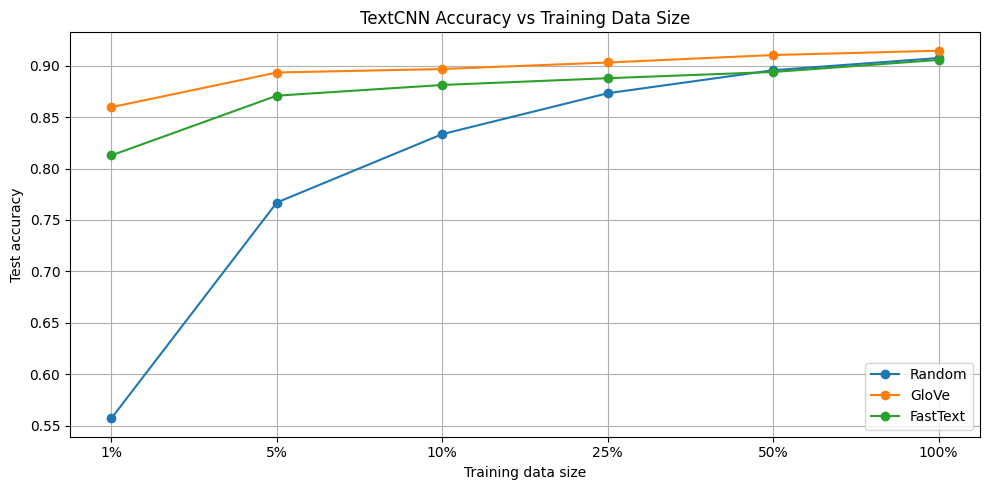

In [ ]:
# Plot test accuracy against training data size

data_sizes = ["1%", "5%", "10%", "25%", "50%", "100%"]

random_acc = [results[f"random_{s}"]["test_accuracy"] for s in data_sizes]
glove_acc = [results[f"glove_{s}"]["test_accuracy"] for s in data_sizes]
fasttext_acc = [results[f"fasttext_{s}"]["test_accuracy"] for s in data_sizes]

plt.figure(figsize=(10, 5))

plt.plot(data_sizes, random_acc, marker="o", label="Random")
plt.plot(data_sizes, glove_acc, marker="o", label="GloVe")
plt.plot(data_sizes, fasttext_acc, marker="o", label="FastText")

plt.title("TextCNN Accuracy vs Training Data Size")
plt.xlabel("Training data size")
plt.ylabel("Test accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("textcnn_accuracy_curve.png", dpi=300, bbox_inches="tight")

plt.show()

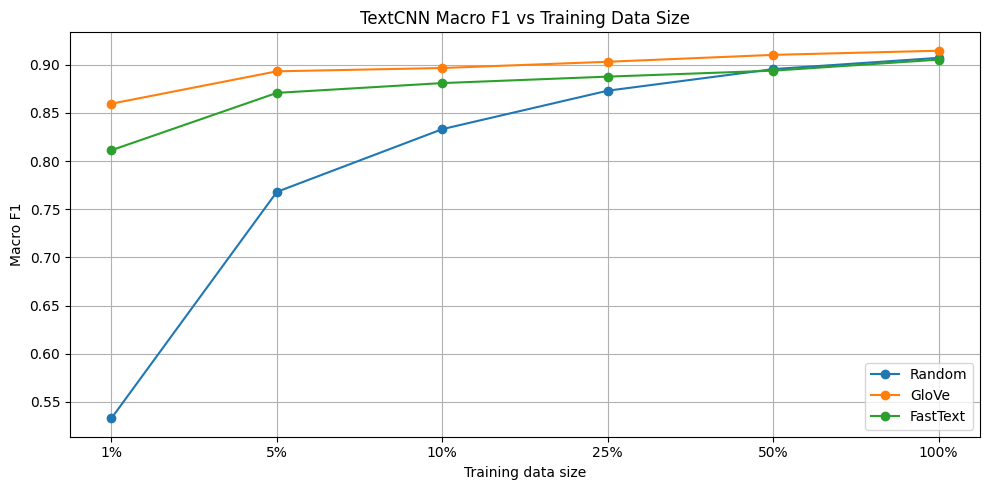

In [ ]:
# Plot macro F1 against training data size

random_f1 = [results[f"random_{s}"]["test_macro_f1"] for s in data_sizes]
glove_f1 = [results[f"glove_{s}"]["test_macro_f1"] for s in data_sizes]
fasttext_f1 = [results[f"fasttext_{s}"]["test_macro_f1"] for s in data_sizes]

plt.figure(figsize=(10, 5))

plt.plot(data_sizes, random_f1, marker="o", label="Random")
plt.plot(data_sizes, glove_f1, marker="o", label="GloVe")
plt.plot(data_sizes, fasttext_f1, marker="o", label="FastText")

plt.title("TextCNN Macro F1 vs Training Data Size")
plt.xlabel("Training data size")
plt.ylabel("Macro F1")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("textcnn_macro_f1_curve.png", dpi=300, bbox_inches="tight")

plt.show()

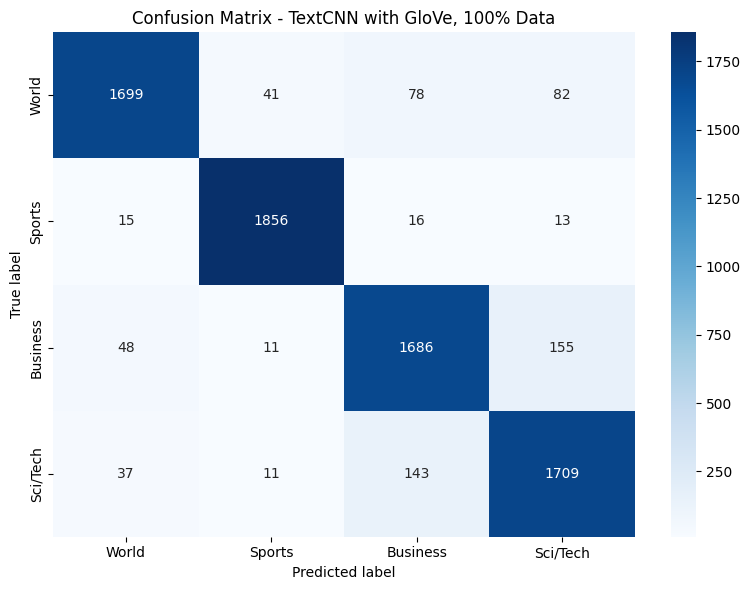

In [ ]:
# Confusion matrix for the best TextCNN data-size run

cm = results["glove_100%"]["confusion_matrix"]

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - TextCNN with GloVe, 100% Data")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

plt.savefig("textcnn_glove_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
# Build and save the final results table
# This table includes train, validation, test, timing, uncertainty, and efficiency metrics.

import pandas as pd
import pickle

rows = []

for key, r in results.items():
    method, size = key.split("_", 1)

    rows.append({
        "method": method,
        "size": size,

        # Final test metrics
        "test_accuracy": r["test_accuracy"],
        "test_macro_f1": r["test_macro_f1"],
        "world_f1": r["world_f1"],
        "sports_f1": r["sports_f1"],
        "business_f1": r["business_f1"],
        "sci_tech_f1": r["sci_tech_f1"],

        # Test uncertainty and errors
        "error_count": r["error_count"],
        "accuracy_ci_low": r["accuracy_ci_low"],
        "accuracy_ci_high": r["accuracy_ci_high"],

        # Training and validation metrics
        "final_train_loss": r["final_train_loss"],
        "best_val_loss": r["best_val_loss"],
        "best_val_accuracy": r["best_val_accuracy"],
        "best_val_macro_f1": r["best_val_macro_f1"],
        "test_loss": r["test_loss"],

        # Timing and throughput
        "train_time": r["train_time"],
        "time_per_epoch": r["time_per_epoch"],
        "approx_gpu_hours": r["approx_gpu_hours"],
        "test_time": r["test_time"],
        "inference_latency_per_example": r["inference_latency_per_example"],
        "test_throughput_examples_per_second": r["test_throughput_examples_per_second"],

        # Dataset and token counts
        "train_examples_total": r["train_examples_total"],
        "train_examples_used": r["train_examples_used"],
        "val_examples_used": r["val_examples_used"],
        "test_examples_used": r["test_examples_used"],
        "avg_input_tokens": r["avg_input_tokens"],
        "max_input_tokens": r["max_input_tokens"],
        "total_train_tokens_seen": r["total_train_tokens_seen"],
        "total_val_tokens_seen": r["total_val_tokens_seen"],
        "total_test_tokens": r["total_test_tokens"],

        # Efficiency ratios
        "accuracy_per_1k_train_examples": r["accuracy_per_1k_train_examples"],
        "accuracy_per_million_train_tokens": r["accuracy_per_million_train_tokens"],

        # Model information
        "vocab_size": r["vocab_size"],
        "total_parameters": r["total_parameters"],

        # Embedding coverage where relevant
        "glove_found": r.get("glove_found", None),
        "glove_coverage": r.get("glove_coverage", None),
        "fasttext_found": r.get("fasttext_found", None),
        "fasttext_coverage": r.get("fasttext_coverage", None)
    })

summary_df = pd.DataFrame(rows)

# Keep rows in a stable order for the report
size_order = {
    "1%": 1,
    "5%": 2,
    "10%": 3,
    "25%": 4,
    "50%": 5,
    "100%": 6
}

method_order = {
    "random": 1,
    "glove": 2,
    "fasttext": 3
}

summary_df["size_order"] = summary_df["size"].map(size_order)
summary_df["method_order"] = summary_df["method"].map(method_order)

summary_df = summary_df.sort_values(["size_order", "method_order"])
summary_df = summary_df.drop(columns=["size_order", "method_order"])
summary_df = summary_df.reset_index(drop=True)

# Save table and full results dictionary
summary_df.to_csv("textcnn_results_extended.csv", index=False)

with open("textcnn_full_results.pkl", "wb") as f:
    pickle.dump(results, f)

print("Saved:")
print("- textcnn_results_extended.csv")
print("- textcnn_full_results.pkl")
print("Rows:", len(summary_df))
print("Columns:", len(summary_df.columns))

if len(summary_df) == 18:
    print("All 18 embedding runs are present")
else:
    print("Warning: expected 18 runs")


Saved:
- textcnn_results_extended.csv
- textcnn_full_results.pkl
Rows: 18
Columns: 39
All 18 embedding runs are present


In [ ]:
# Quick check of the final results table

print("Number of experiments:", len(results))
print("summary_df rows:", len(summary_df))
print("summary_df columns:", len(summary_df.columns))
print("Methods:", summary_df["method"].unique())
print("Sizes:", summary_df["size"].unique())

if len(results) == 18 and len(summary_df) == 18:
    print("Final results table is complete")
else:
    print("Warning: expected 18 experiments")

Number of experiments: 18
summary_df rows: 18
summary_df columns: 39
Methods: ['random' 'glove' 'fasttext']
Sizes: ['1%' '5%' '10%' '25%' '50%' '100%']
Final results table is complete


In [ ]:
# Add data-efficiency metrics
# Retention compares each run with the 100% data result for the same method.
# Marginal gain shows the accuracy improvement from the previous data size.

summary_df = summary_df.copy()

size_order_list = ["1%", "5%", "10%", "25%", "50%", "100%"]

summary_df["size"] = pd.Categorical(
    summary_df["size"],
    categories=size_order_list,
    ordered=True
)

# Retention = test accuracy at this size / test accuracy at 100% data
full_accuracy = summary_df[summary_df["size"] == "100%"].set_index("method")["test_accuracy"]

summary_df["accuracy_retention"] = summary_df.apply(
    lambda row: row["test_accuracy"] / full_accuracy[row["method"]],
    axis=1
)

# Marginal gain = test accuracy improvement from the previous data size
summary_df = summary_df.sort_values(["method", "size"])
summary_df["accuracy_marginal_gain"] = summary_df.groupby("method")["test_accuracy"].diff()

# Put rows back into report order
method_order = {
    "random": 1,
    "glove": 2,
    "fasttext": 3
}

summary_df["method_order"] = summary_df["method"].map(method_order)

summary_df = summary_df.sort_values(["size", "method_order"])
summary_df = summary_df.drop(columns=["method_order"])
summary_df = summary_df.reset_index(drop=True)

# Save again so the CSV includes the new efficiency columns
summary_df.to_csv("textcnn_results_extended.csv", index=False)

print("Added data-efficiency metrics")
print("Saved updated CSV file")
print("Rows:", len(summary_df))
print("Columns:", len(summary_df.columns))

summary_df

Added data-efficiency metrics
Saved updated CSV file
Rows: 18
Columns: 41


,method,size,test_accuracy,test_macro_f1,world_f1,sports_f1,business_f1,sci_tech_f1,error_count,accuracy_ci_low,...,accuracy_per_1k_train_examples,accuracy_per_million_train_tokens,vocab_size,total_parameters,glove_found,glove_coverage,fasttext_found,fasttext_coverage,accuracy_retention,accuracy_marginal_gain
0,random,1%,0.557237,0.532950,0.407643,0.656531,0.586528,0.481098,3365,0.546069,...,0.488804,1.955217,10952,1216704,NaN,NaN,NaN,NaN,0.614124,NaN
1,glove,1%,0.859605,0.859587,0.866580,0.931536,0.821251,0.818982,1067,0.851795,...,0.754040,3.016159,10952,1216704,7797.0,71.192476,NaN,NaN,0.940000,NaN
2,fasttext,1%,0.812763,0.811271,0.844420,0.872727,0.773037,0.754899,1423,0.803993,...,0.712950,2.851801,10952,1216704,NaN,NaN,7895.0,72.087290,0.897559,NaN
3,random,5%,0.766974,0.768037,0.783746,0.851131,0.722094,0.715177,1771,0.757469,...,0.134557,0.538227,20002,2121704,NaN,NaN,NaN,NaN,0.845273,0.209737
4,glove,5%,0.893289,0.893196,0.894612,0.960357,0.854405,0.863411,811,0.886348,...,0.156717,0.626870,20002,2121704,13634.0,68.163184,NaN,NaN,0.976835,0.033684
5,fasttext,5%,0.870789,0.870812,0.876120,0.943218,0.828210,0.835701,982,0.863248,...,0.152770,0.611080,20002,2121704,NaN,NaN,13722.0,68.603140,0.961639,0.058026
6,random,10%,0.833421,0.833164,0.844668,0.910463,0.785131,0.792393,1266,0.825044,...,0.073107,0.292428,20002,2121704,NaN,NaN,NaN,NaN,0.918503,0.066447
7,glove,10%,0.896711,0.896635,0.902458,0.963157,0.857215,0.863711,785,0.889868,...,0.078659,0.314635,20002,2121704,14802.0,74.002600,NaN,NaN,0.980576,0.003421
8,fasttext,10%,0.881184,0.880987,0.889065,0.945038,0.838488,0.851355,903,0.873909,...,0.077297,0.309187,20002,2121704,NaN,NaN,14928.0,74.632537,0.973118,0.010395
9,random,25%,0.873158,0.873104,0.880625,0.935207,0.832761,0.843823,964,0.865676,...,0.030637,0.122548,20002,2121704,NaN,NaN,NaN,NaN,0.962297,0.039737


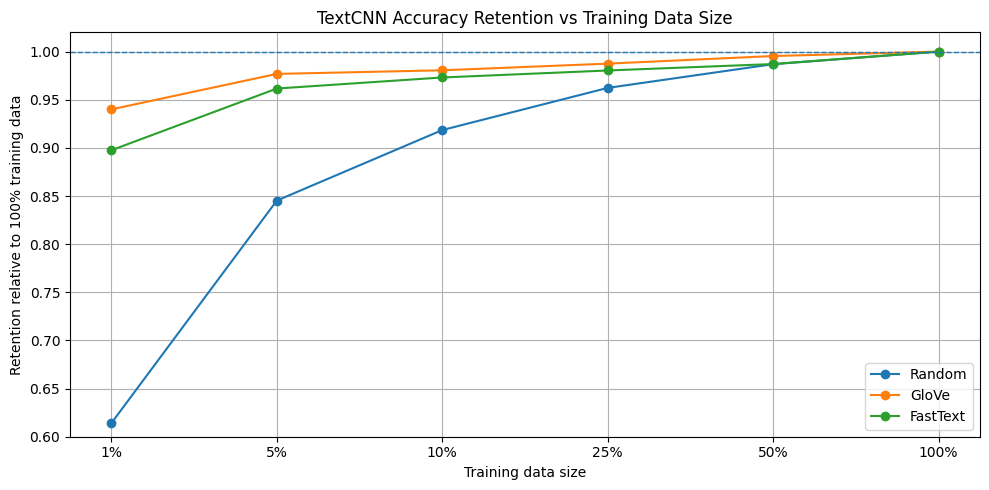

In [ ]:
# Accuracy retention graph
# Retention compares each run with the 100% data result for the same method.

size_order = ["1%", "5%", "10%", "25%", "50%", "100%"]

plot_df = summary_df.copy()
plot_df["size"] = pd.Categorical(plot_df["size"], categories=size_order, ordered=True)
plot_df = plot_df.sort_values(["size", "method"])

random_ret = plot_df[plot_df["method"] == "random"]["accuracy_retention"]
glove_ret = plot_df[plot_df["method"] == "glove"]["accuracy_retention"]
fasttext_ret = plot_df[plot_df["method"] == "fasttext"]["accuracy_retention"]

plt.figure(figsize=(10, 5))

plt.plot(size_order, random_ret, marker="o", label="Random")
plt.plot(size_order, glove_ret, marker="o", label="GloVe")
plt.plot(size_order, fasttext_ret, marker="o", label="FastText")

plt.axhline(y=1.0, linestyle="--", linewidth=1)

plt.title("TextCNN Accuracy Retention vs Training Data Size")
plt.xlabel("Training data size")
plt.ylabel("Retention relative to 100% training data")
plt.ylim(0.6, 1.02)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("textcnn_accuracy_retention_curve.png", dpi=300, bbox_inches="tight")

plt.show()

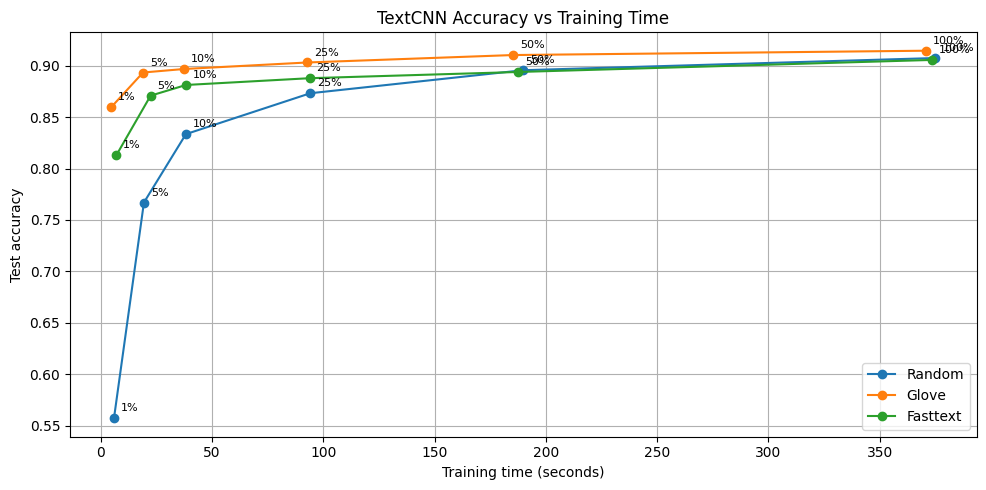

In [ ]:
# Accuracy vs training time
# This shows the trade-off between performance and training cost.

plt.figure(figsize=(10, 5))

for method in ["random", "glove", "fasttext"]:
    method_df = summary_df[summary_df["method"] == method].copy()
    method_df = method_df.sort_values("train_time")

    plt.plot(
        method_df["train_time"],
        method_df["test_accuracy"],
        marker="o",
        label=method.capitalize()
    )

    for _, row in method_df.iterrows():
        plt.annotate(
            row["size"],
            (row["train_time"], row["test_accuracy"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8
        )

plt.title("TextCNN Accuracy vs Training Time")
plt.xlabel("Training time (seconds)")
plt.ylabel("Test accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("textcnn_accuracy_vs_train_time.png", dpi=300, bbox_inches="tight")

plt.show()

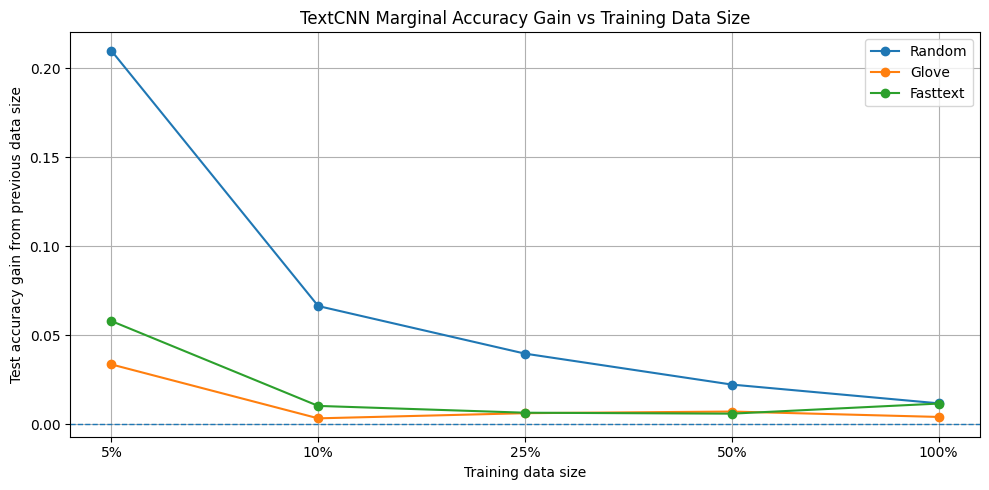

In [ ]:
# Marginal accuracy gain graph
# This shows how much test accuracy improves when moving to the next data size.

size_order = ["1%", "5%", "10%", "25%", "50%", "100%"]

plot_df = summary_df.copy()
plot_df["size"] = pd.Categorical(plot_df["size"], categories=size_order, ordered=True)
plot_df = plot_df.sort_values(["method", "size"])

plt.figure(figsize=(10, 5))

for method in ["random", "glove", "fasttext"]:
    method_df = plot_df[plot_df["method"] == method]

    plt.plot(
        method_df["size"].astype(str),
        method_df["accuracy_marginal_gain"],
        marker="o",
        label=method.capitalize()
    )

plt.axhline(y=0, linestyle="--", linewidth=1)

plt.title("TextCNN Marginal Accuracy Gain vs Training Data Size")
plt.xlabel("Training data size")
plt.ylabel("Test accuracy gain from previous data size")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("textcnn_marginal_accuracy_gain.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
# Final check that all expected files were saved

import os

needed_files = [
    "textcnn_results_extended.csv",
    "textcnn_full_results.pkl",
    "textcnn_accuracy_curve.png",
    "textcnn_macro_f1_curve.png",
    "textcnn_glove_confusion_matrix.png",
    "textcnn_accuracy_retention_curve.png",
    "textcnn_accuracy_vs_train_time.png",
    "textcnn_marginal_accuracy_gain.png"
]
missing_files = []

for file in needed_files:
    exists = os.path.exists(file)
    print(file, "exists:", exists)

    if not exists:
        missing_files.append(file)

if len(missing_files) == 0:
    print("All expected files were saved")
else:
    print("Missing files:", missing_files)

textcnn_results_extended.csv exists: True
textcnn_full_results.pkl exists: True
textcnn_accuracy_curve.png exists: True
textcnn_macro_f1_curve.png exists: True
textcnn_glove_confusion_matrix.png exists: True
textcnn_accuracy_retention_curve.png exists: True
textcnn_accuracy_vs_train_time.png exists: True
textcnn_marginal_accuracy_gain.png exists: True
All expected files were saved


In [ ]:
# Test any saved TextCNN embedding weight without retraining

import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# list uploaded weight files
weight_files = sorted([f for f in os.listdir() if f.endswith(".pth")])

print("Available weight files:")
for i, f in enumerate(weight_files):
    print(i, f)

# choose one file by index
# change 0 to another index if needed
WEIGHTS_FILE = weight_files[0]

print("Testing:", WEIGHTS_FILE)
print("Weight exists:", os.path.exists(WEIGHTS_FILE))

# expected filename examples:
# textcnn_random_1pct_seed42.pth
# textcnn_glove_100pct_seed42.pth
# textcnn_fasttext_50pct_seed42.pth

parts = WEIGHTS_FILE.replace(".pth", "").split("_")
embedding_type = parts[1]
fraction_tag = parts[2]

fraction_map = {
    "1pct": 0.01,
    "5pct": 0.05,
    "10pct": 0.10,
    "25pct": 0.25,
    "50pct": 0.50,
    "100pct": 1.00
}

data_fraction = fraction_map[fraction_tag]

train_texts_run, train_labels_run = create_subset(
    train_pool_texts,
    train_pool_labels,
    data_fraction,
    seed=SEED
)

X_train, y_train, X_val, y_val, X_test, y_test, vocab, word2idx = prepare_data(
    train_texts_run,
    train_labels_run,
    test_texts,
    test_labels
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=BATCH_SIZE
)

model = TextCNN(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    num_classes=NUM_CLASSES,
    num_filters=NUM_FILTERS,
    filter_sizes=FILTER_SIZES
).to(device)

if embedding_type == "glove":
    embedding_matrix, found = build_glove_matrix(
        vocab,
        word2idx,
        glove,
        EMBED_DIM
    )
    model.embedding.weight.data.copy_(
        torch.tensor(embedding_matrix, dtype=torch.float32).to(device)
    )

elif embedding_type == "fasttext":
    embedding_matrix, found = build_fasttext_matrix(
        vocab,
        word2idx,
        fasttext,
        EMBED_DIM
    )
    model.embedding.weight.data.copy_(
        torch.tensor(embedding_matrix, dtype=torch.float32).to(device)
    )

elif embedding_type == "random":
    pass

else:
    raise ValueError("Unknown embedding type in weight filename")

model.load_state_dict(torch.load(WEIGHTS_FILE, map_location=device))
model.eval()

criterion = nn.CrossEntropyLoss()

test_loss, test_acc, test_f1, f1_per_class, cm = evaluate(
    model,
    test_loader,
    criterion
)

print("Loaded weights:", WEIGHTS_FILE)
print("Embedding:", embedding_type)
print("Data fraction:", fraction_tag)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test macro F1: {test_f1:.4f}")
print("Per-class F1:", f1_per_class)
print("Confusion matrix:")
print(cm)

# TextCNN AG News Short-Context Experiment

**Saman Zobeiry**

**Model:** TextCNN with GloVe embeddings  
**Dataset:** AG News  
**Experiment:** : Short-context word-budget experiment using first-N, random-N, TF-IDF-N, and RoBERTa-attention-selected salient words
Note: TextCNN is the classifier; RoBERTa is used only to select salient words.

In [ ]:
# Optional: W&B logging for experiment tracking
USE_WANDB = False

if USE_WANDB:
    !pip install -q wandb
    import wandb
    wandb.login()

In [ ]:
# Install the dataset library used to load AG News
!pip install -q datasets

In [ ]:
# Import libraries and set GPU/CPU device

import os
import re
import time
import copy
import random
import pickle
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# Project settings
SEED = 42
MODEL_NAME = "textcnn"
EMBEDDING_NAME = "glove"
DATASET_NAME = "agnews"

print("Dataset:", DATASET_NAME)
print("Model:", MODEL_NAME)
print("Embedding:", EMBEDDING_NAME)
print("Seed:", SEED)

Dataset: agnews
Model: textcnn
Embedding: glove
Seed: 42


In [ ]:
# Load the AG News dataset
from datasets import load_dataset
dataset = load_dataset("ag_news")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [ ]:
# Text preprocessing and tensor preparation functions

MAX_LEN = 50
VOCAB_SIZE = 20000

# Split text into words
def word_tokenize(text):
    return str(text).lower().split()

# Keep old function name so later code still works
def tokenize(text):
    return word_tokenize(text)

# Take a smaller balanced part of the fixed training pool
def create_subset(texts, labels, fraction, seed=42):
    if fraction == 1.0:
        return texts, labels

    subset_texts, unused_texts, subset_labels, unused_labels = train_test_split(
        texts,
        labels,
        train_size=fraction,
        stratify=labels,
        random_state=seed
    )

    return subset_texts, subset_labels

# Build vocab from the current training split only
def build_vocab(texts):
    all_words = []

    for text in texts:
        all_words.extend(word_tokenize(text))

    word_counts = Counter(all_words)

    vocab = ["<PAD>", "<UNK>"] + [
        word for word, count in word_counts.most_common(VOCAB_SIZE)
    ]

    word2idx = {word: idx for idx, word in enumerate(vocab)}

    return vocab, word2idx

# Convert one article to a fixed length list of word indexes
def text_to_sequence(text, word2idx):
    tokens = word_tokenize(text)
    seq = [word2idx.get(word, 1) for word in tokens]  # 1 is <UNK>

    if len(seq) < MAX_LEN:
        seq = seq + [0] * (MAX_LEN - len(seq))        # 0 is <PAD>
    else:
        seq = seq[:MAX_LEN]

    return seq

# Prepare tensors for one run using the fixed validation and test sets
def prepare_data(train_texts_run, train_labels_run, val_texts, val_labels, test_texts, test_labels):
    vocab, word2idx = build_vocab(train_texts_run)

    train_seqs = [text_to_sequence(text, word2idx) for text in train_texts_run]
    val_seqs = [text_to_sequence(text, word2idx) for text in val_texts]
    test_seqs = [text_to_sequence(text, word2idx) for text in test_texts]

    X_train = torch.tensor(train_seqs, dtype=torch.long)
    y_train = torch.tensor(train_labels_run, dtype=torch.long)

    X_val = torch.tensor(val_seqs, dtype=torch.long)
    y_val = torch.tensor(val_labels, dtype=torch.long)

    X_test = torch.tensor(test_seqs, dtype=torch.long)
    y_test = torch.tensor(test_labels, dtype=torch.long)

    return X_train, y_train, X_val, y_val, X_test, y_test, vocab, word2idx

In [ ]:
# Quick look at a few raw AG News examples
print(dataset["train"][0])
print(dataset["train"][1])
print(dataset["train"][2])

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}
{'text': 'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\\which has a reputation for making well-timed and occasionally\\controversial plays in the defense industry, has quietly placed\\its bets on another part of the market.', 'label': 2}
{'text': "Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\\about the economy and the outlook for earnings are expected to\\hang over the stock market next week during the depth of the\\summer doldrums.", 'label': 2}


In [ ]:
# Check class balance in the training set
from collections import Counter
labels = [x['label'] for x in dataset['train']]
print(Counter(labels))

Counter({2: 30000, 3: 30000, 1: 30000, 0: 30000})


In [ ]:
# Show the label names used by the dataset
print(dataset['train'].features['label'].names)

['World', 'Sports', 'Business', 'Sci/Tech']


In [ ]:
# Put dataset text and labels into simple Python lists
# Then create one fixed 5% validation split from the original training set

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

all_train_texts = [example["text"] for example in dataset["train"]]
all_train_labels = [example["label"] for example in dataset["train"]]

test_texts = [example["text"] for example in dataset["test"]]
test_labels = [example["label"] for example in dataset["test"]]

class_names = dataset["train"].features["label"].names

train_pool_texts, val_texts, train_pool_labels, val_labels = train_test_split(
    all_train_texts,
    all_train_labels,
    test_size=0.05,
    stratify=all_train_labels,
    random_state=SEED
)

print(f"Original training articles: {len(all_train_texts)}")
print(f"Training pool after 5% validation split: {len(train_pool_texts)}")
print(f"Validation articles: {len(val_texts)}")
print(f"Test articles: {len(test_texts)}")
print(f"Classes: {class_names}")
print("Train pool class balance:", Counter(train_pool_labels))
print("Validation class balance:", Counter(val_labels))

Original training articles: 120000
Training pool after 5% validation split: 114000
Validation articles: 6000
Test articles: 7600
Classes: ['World', 'Sports', 'Business', 'Sci/Tech']
Train pool class balance: Counter({1: 28500, 3: 28500, 0: 28500, 2: 28500})
Validation class balance: Counter({0: 1500, 2: 1500, 3: 1500, 1: 1500})


In [ ]:
# Check average article length before the word-budget runs

train_word_lengths = [len(word_tokenize(text)) for text in train_pool_texts]
val_word_lengths = [len(word_tokenize(text)) for text in val_texts]
test_word_lengths = [len(word_tokenize(text)) for text in test_texts]

avg_train_words = np.mean(train_word_lengths)
avg_val_words = np.mean(val_word_lengths)
avg_test_words = np.mean(test_word_lengths)

print(f"Average train article length: {avg_train_words:.2f} words")
print(f"Average validation article length: {avg_val_words:.2f} words")
print(f"Average test article length: {avg_test_words:.2f} words")
print(f"Fixed TextCNN input length: {MAX_LEN} words")

Average train article length: 37.85 words
Average validation article length: 37.79 words
Average test article length: 37.72 words
Fixed TextCNN input length: 50 words


In [ ]:
# Check word counts

all_lengths = [len(word_tokenize(text)) for text in all_train_texts]

print("Train articles:", len(all_lengths))
print("Mean words:", round(np.mean(all_lengths), 2))
print("Median words:", np.median(all_lengths))
print("Min words:", np.min(all_lengths))
print("Max words:", np.max(all_lengths))
print("95th percentile:", np.percentile(all_lengths, 95))

print("\nFirst 3 examples:")
for i in range(3):
    print("-" * 60)
    print("Words:", len(word_tokenize(all_train_texts[i])))
    print(all_train_texts[i])

Train articles: 120000
Mean words: 37.85
Median words: 37.0
Min words: 8
Max words: 177
95th percentile: 53.0

First 3 examples:
------------------------------------------------------------
Words: 21
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
------------------------------------------------------------
Words: 36
Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
------------------------------------------------------------
Words: 36
Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.


In [ ]:
# Quick preprocessing test that creates the expected tensor shapes

sample_texts = train_pool_texts[:1000]
sample_labels = train_pool_labels[:1000]

X_train_sample, y_train_sample, X_val_sample, y_val_sample, X_test_sample, y_test_sample, vocab, word2idx = prepare_data(
    sample_texts,
    sample_labels,
    val_texts,
    val_labels,
    test_texts,
    test_labels
)

print("Sample X_train shape:", X_train_sample.shape)
print("Sample X_val shape:", X_val_sample.shape)
print("Sample X_test shape:", X_test_sample.shape)
print("Vocabulary size:", len(vocab))

Sample X_train shape: torch.Size([1000, 50])
Sample X_val shape: torch.Size([6000, 50])
Sample X_test shape: torch.Size([7600, 50])
Vocabulary size: 10053


In [ ]:
# TextCNN model used in the short-context runs

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes,
                 num_filters=100, filter_sizes=None, dropout=0.5):
        super(TextCNN, self).__init__()

        if filter_sizes is None:
            filter_sizes = [3, 4, 5]

        self.filter_sizes = filter_sizes

        # Turns word ids into embedding vectors
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Filters look at 3-word, 4-word, and 5-word windows
        self.convs = nn.ModuleList([
            nn.Conv2d(1, num_filters, (fs, embed_dim))
            for fs in filter_sizes
        ])

        # Dropout used before the final layer
        self.dropout = nn.Dropout(dropout)

        # Final layer gives one score/logit for each class
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        # Input shape: batch_size x sequence_length
        x = self.embedding(x)

        # Shape becomes: batch_size x sequence_length x embed_dim
        # Add one channel dimension for Conv2d
        x = x.unsqueeze(1)

        # Run each CNN filter and max-pool its output
        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(x)).squeeze(3)
            c = torch.max_pool1d(c, c.size(2)).squeeze(2)
            pooled.append(c)

        # Join all pooled filter outputs
        x = torch.cat(pooled, dim=1)

        # Apply dropout before classification
        x = self.dropout(x)

        # Return raw logits; CrossEntropyLoss applies softmax internally
        return self.fc(x)

print("TextCNN model ready")

TextCNN model ready


In [ ]:
# Training and evaluation functions

def train_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        output = model(X_batch)
        loss = criterion(output, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion, return_extra=False):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            output = model(X_batch)
            loss = criterion(output, y_batch)

            preds = output.argmax(dim=1).cpu().numpy()

            total_loss += loss.item()
            all_preds.extend(preds)
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    f1_per_class = f1_score(all_labels, all_preds, average=None)
    cm = confusion_matrix(all_labels, all_preds)

    if return_extra:
        precision_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0)
        recall_macro = recall_score(all_labels, all_preds, average="macro", zero_division=0)
        error_count = int(np.sum(np.array(all_preds) != np.array(all_labels)))

        extra = {
            "precision_macro": precision_macro,
            "recall_macro": recall_macro,
            "error_count": error_count,
            "labels": all_labels,
            "preds": all_preds
        }

        return avg_loss, acc, f1_macro, f1_per_class, cm, extra

    return avg_loss, acc, f1_macro, f1_per_class, cm


print("Training and evaluation functions ready")

Training and evaluation functions ready


In [ ]:
# Main settings for the TextCNN runs

EMBED_DIM = 100
NUM_CLASSES = 4
EPOCHS = 5
BATCH_SIZE = 64

# Short-context settings
DATA_FRACTIONS = [0.50, 1.00]
WORD_BUDGETS = [16, 20, 52]
CONTEXT_METHODS = ["first_n", "random_n", "salient_n"]

print("Experiment settings ready")
print("Data fractions:", DATA_FRACTIONS)
print("Word budgets:", WORD_BUDGETS)
print("Context methods:", CONTEXT_METHODS)

Experiment settings ready
Data fractions: [0.5, 1.0]
Word budgets: [16, 20, 52]
Context methods: ['first_n', 'random_n', 'salient_n']


In [ ]:
# Load GloVe word vectors

import urllib.request
import zipfile
import os

# Download GloVe if it is not already here
if not os.path.exists("glove.6B.100d.txt"):
    print("Downloading GloVe vectors...")
    urllib.request.urlretrieve(
        "https://nlp.stanford.edu/data/glove.6B.zip",
        "glove.6B.zip"
    )

    print("Extracting...")
    with zipfile.ZipFile("glove.6B.zip", "r") as f:
        f.extract("glove.6B.100d.txt")

    print("Done")
else:
    print("GloVe already downloaded")

# Read word vectors into a dictionary
print("Loading GloVe vectors...")

glove = {}

with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        parts = line.split()
        word = parts[0]
        vector = np.array(parts[1:], dtype=np.float32)
        glove[word] = vector

print(f"GloVe loaded: {len(glove)} words")

# check that common news words are covered
print(f"'profit' in GloVe: {'profit' in glove}")
print(f"'tournament' in GloVe: {'tournament' in glove}")
print(f"'world' in GloVe: {'world' in glove}")

GloVe already downloaded
Loading GloVe vectors...
GloVe loaded: 400000 words
'profit' in GloVe: True
'tournament' in GloVe: True
'world' in GloVe: True


In [ ]:
# Build a GloVe embedding matrix for the current vocabulary

def build_glove_matrix(vocab, word2idx, glove, embed_dim=100):
    # Start with random vectors for words not found in GloVe
    embedding_matrix = np.random.uniform(
        -0.1,
        0.1,
        (len(vocab), embed_dim)
    ).astype(np.float32)

    # Keep padding vector as zeros
    embedding_matrix[0] = np.zeros(embed_dim)

    # Replace random vectors with GloVe vectors when available
    found = 0

    for word, idx in word2idx.items():
        if word in glove:
            embedding_matrix[idx] = glove[word]
            found += 1

    return embedding_matrix, found


In [ ]:
# Count TextCNN parameters for result logging

NUM_FILTERS = 100
FILTER_SIZES = [3, 4, 5]

def count_textcnn_params(vocab_size):
    # Embedding layer parameters
    embedding_params = vocab_size * EMBED_DIM

    # Convolution filter parameters
    conv_params = sum(
        NUM_FILTERS * (filter_size * EMBED_DIM + 1)
        for filter_size in FILTER_SIZES
    )

    # Final linear layer parameters
    fc_params = (NUM_FILTERS * len(FILTER_SIZES) * NUM_CLASSES) + NUM_CLASSES

    return embedding_params + conv_params + fc_params

In [ ]:
# Check which files are currently available in Colab

import os

for file in os.listdir():
    print(file)

.config
agnews_textcnn_glove_random52_100pct_seed42.pth
sample_data


In [ ]:
# Set up data sizes, word budgets, and word selection methods

short_context_data_sizes = {
    "50%": 0.50,
    "100%": 1.00
}

word_budgets = WORD_BUDGETS
context_methods = CONTEXT_METHODS

short_context_results = {}

print("Short-context setup ready")
print("Data sizes:", list(short_context_data_sizes.keys()))
print("Word budgets:", word_budgets)
print("Methods:", context_methods)

Short-context setup ready
Data sizes: ['50%', '100%']
Word budgets: [16, 20, 52]
Methods: ['first_n', 'random_n', 'salient_n']


In [ ]:
# Load RoBERTa to select important words
# TextCNN is still the classifier
!pip install -q transformers

from transformers import AutoTokenizer, AutoModelForSequenceClassification

roberta_model_name = "textattack/roberta-base-ag-news"

roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_model_name)

roberta_selector = AutoModelForSequenceClassification.from_pretrained(
    roberta_model_name,
    attn_implementation="eager"
)

roberta_selector = roberta_selector.to(device)
roberta_selector.eval()

print("RoBERTa selector loaded")
print("Device:", device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: textattack/roberta-base-ag-news
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RoBERTa selector loaded
Device: cuda


In [ ]:
# Basic word selection functions
# These functions create shortened versions of each AG News article.

def first_n_words(text, n):
    # Keep the first N words in the original order
    words = word_tokenize(text)
    return " ".join(words[:n])


def random_n_words(text, n, seed=42):
    # Pick N random words, then restore their original order
    words = word_tokenize(text)

    if len(words) <= n:
        return " ".join(words)

    rng = np.random.default_rng(seed)

    # choose N word positions without replacement
    picked_positions = rng.choice(len(words), size=n, replace=False)

    # sort positions so the shortened text keeps article order
    picked_positions = sorted(picked_positions)

    return " ".join([words[pos] for pos in picked_positions])


def fit_tfidf_vectorizer(texts):
    # Fit TF-IDF using the training pool only
    # This avoids using test data when scoring important words.
    vectorizer = TfidfVectorizer(
        tokenizer=word_tokenize,
        lowercase=False,
        token_pattern=None
    )

    vectorizer.fit(texts)

    return vectorizer


def tfidf_n_words(text, n, vectorizer):
    # Keep the N words with the highest TF-IDF scores in this article
    words = word_tokenize(text)

    if len(words) <= n:
        return " ".join(words)

    row = vectorizer.transform([text])
    feature_names = vectorizer.get_feature_names_out()

    word_scores = {}
    for idx, score in zip(row.indices, row.data):
        word_scores[feature_names[idx]] = score

    positions = []
    for i, word in enumerate(words):
        positions.append((i, word_scores.get(word, 0)))

    top_positions = sorted(
        positions,
        key=lambda x: x[1],
        reverse=True
    )[:n]

    top_indices = sorted([pos for pos, score in top_positions])

    return " ".join([words[i] for i in top_indices])

print("Basic word selection functions ready")

Basic word selection functions ready


In [ ]:
# RoBERTa word selection
# This is used only for the salient_n condition.
# TextCNN is still the classifier; RoBERTa only helps choose words.

roberta_word_score_cache = {}

def score_words_with_roberta(text):
    # Reuse scores if this article was already checked
    if text in roberta_word_score_cache:
        return roberta_word_score_cache[text]

    clean_text = str(text).lower()
    word_matches = list(re.finditer(r"\S+", clean_text))
    words = [match.group(0) for match in word_matches]

    if len(words) == 0:
        roberta_word_score_cache[text] = []
        return []

    # Tokenize with RoBERTa and keep character offsets
    encoded = roberta_tokenizer(
        clean_text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        return_offsets_mapping=True
    )

    offsets = encoded.pop("offset_mapping")[0].tolist()
    encoded = encoded.to(device)

    with torch.no_grad():
        output = roberta_selector(**encoded, output_attentions=True)

    # Use final-layer attention from the class token as a salience heuristic
    last_attention = output.attentions[-1][0]
    token_scores = last_attention[:, 0, :].mean(dim=0).detach().cpu().numpy()

    word_scores = np.zeros(len(words), dtype=np.float32)

    # Map RoBERTa token scores back to normal words
    for token_pos, (start, end) in enumerate(offsets):
        if start == end:
            continue

        for word_pos, match in enumerate(word_matches):
            word_start, word_end = match.span()

            if end <= word_start:
                break

            if start < word_end and end > word_start:
                word_scores[word_pos] = max(word_scores[word_pos], token_scores[token_pos])

    scored_words = [(i, words[i], word_scores[i]) for i in range(len(words))]
    roberta_word_score_cache[text] = scored_words

    return scored_words


def roberta_salient_n_words(text, n):
    # Keep the N highest-scoring words
    scored_words = score_words_with_roberta(text)

    if len(scored_words) <= n:
        return " ".join([word for _, word, _ in scored_words])

    # Pick top N by RoBERTa attention score
    picked_words = sorted(scored_words, key=lambda x: x[2], reverse=True)[:n]

    # Put selected words back into article order
    picked_words = sorted(picked_words, key=lambda x: x[0])

    return " ".join([word for _, word, _ in picked_words])


print("RoBERTa salient word selection ready")

RoBERTa salient word selection ready


In [ ]:
# Check that the training setup is ready

needed_items = [
    # data splits
    "train_pool_texts",
    "train_pool_labels",
    "val_texts",
    "val_labels",
    "test_texts",
    "test_labels",

    # preprocessing
    "word_tokenize",
    "tokenize",
    "create_subset",
    "prepare_data",
    "build_vocab",
    "text_to_sequence",

    # embeddings/model
    "build_glove_matrix",
    "glove",
    "TextCNN",

    # training/evaluation
    "train_epoch",
    "evaluate",
    "device",

    # settings
    "EMBED_DIM",
    "NUM_CLASSES",
    "EPOCHS",
    "BATCH_SIZE",
    "short_context_data_sizes",
    "word_budgets",
    "context_methods",

    # word selection methods
    "first_n_words",
    "random_n_words",
    "fit_tfidf_vectorizer",
    "tfidf_n_words",
    "roberta_salient_n_words"
]

missing_items = [name for name in needed_items if name not in globals()]

if missing_items:
    print("Missing items:")
    for name in missing_items:
        print("-", name)
else:
    print("All needed items are ready")

Missing items:
- build_glove_matrix
- glove
- roberta_salient_n_words


In [ ]:
USE_WANDB = False

In [ ]:
# Save results during the experiment

import os
import pickle
import pandas as pd

def save_short_context_checkpoint(results_dict):
    rows = []

    for run_name, result in results_dict.items():
        row = {"run_name": run_name}

        for key, value in result.items():
            if key not in [
                "confusion_matrix",
                "train_losses",
                "val_losses",
                "val_accuracies",
                "val_macro_f1s"
            ]:
                row[key] = value

        rows.append(row)

    results_table = pd.DataFrame(rows)
    results_table.to_csv("textcnn_short_context_results.csv", index=False)

    with open("textcnn_short_context_results.pkl", "wb") as f:
        pickle.dump(results_dict, f)

    print("Checkpoint saved:", len(results_dict), "runs")

In [ ]:
# Make full or shortened train/validation/test texts

def make_context_texts(method_name, train_texts_run, val_texts, test_texts, word_budget=None, tfidf_vectorizer=None):
    # Full baseline: keep original article text
    if method_name == "full":
        return train_texts_run, val_texts, test_texts

    if method_name == "first_n":
        short_train_texts = [
            first_n_words(text, word_budget)
            for text in train_texts_run
        ]

        short_val_texts = [
            first_n_words(text, word_budget)
            for text in val_texts
        ]

        short_test_texts = [
            first_n_words(text, word_budget)
            for text in test_texts
        ]

    elif method_name == "random_n":
        short_train_texts = [
            random_n_words(text, word_budget, seed=SEED + i)
            for i, text in enumerate(train_texts_run)
        ]

        short_val_texts = [
            random_n_words(text, word_budget, seed=500 + i)
            for i, text in enumerate(val_texts)
        ]

        short_test_texts = [
            random_n_words(text, word_budget, seed=1000 + i)
            for i, text in enumerate(test_texts)
        ]

    elif method_name == "tfidf_n":
        if tfidf_vectorizer is None:
            raise ValueError("tfidf_vectorizer is needed for tfidf_n")

        short_train_texts = [
            tfidf_n_words(text, word_budget, tfidf_vectorizer)
            for text in train_texts_run
        ]

        short_val_texts = [
            tfidf_n_words(text, word_budget, tfidf_vectorizer)
            for text in val_texts
        ]

        short_test_texts = [
            tfidf_n_words(text, word_budget, tfidf_vectorizer)
            for text in test_texts
        ]

    elif method_name == "salient_n":
        short_train_texts = [
            roberta_salient_n_words(text, word_budget)
            for text in train_texts_run
        ]

        short_val_texts = [
            roberta_salient_n_words(text, word_budget)
            for text in val_texts
        ]

        short_test_texts = [
            roberta_salient_n_words(text, word_budget)
            for text in test_texts
        ]

    else:
        raise ValueError(f"Unknown method: {method_name}")

    return short_train_texts, short_val_texts, short_test_texts


print("Context text creation function ready")

Context text creation function ready


In [ ]:
# Test uploaded saved weight without retraining

import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

WEIGHTS_FILE = "agnews_textcnn_glove_random52_100pct_seed42.pth"

print("Weight exists:", os.path.exists(WEIGHTS_FILE))

train_texts_run = train_pool_texts
train_labels_run = train_pool_labels

short_train_texts, short_val_texts, short_test_texts = make_context_texts(
    method_name="random_n",
    train_texts_run=train_texts_run,
    val_texts=val_texts,
    test_texts=test_texts,
    word_budget=52,
    tfidf_vectorizer=None
)

X_train, y_train, X_val, y_val, X_test, y_test, vocab, word2idx = prepare_data(
    short_train_texts,
    train_labels_run,
    short_val_texts,
    val_labels,
    short_test_texts,
    test_labels
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=BATCH_SIZE
)

model = TextCNN(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    num_classes=NUM_CLASSES,
    num_filters=NUM_FILTERS,
    filter_sizes=FILTER_SIZES
).to(device)

model.load_state_dict(torch.load(WEIGHTS_FILE, map_location=device))
model.eval()

criterion = nn.CrossEntropyLoss()

test_loss, test_acc, test_f1, f1_per_class, cm, extra = evaluate(
    model,
    test_loader,
    criterion,
    return_extra=True
)

print("Loaded weights:", WEIGHTS_FILE)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test macro F1: {test_f1:.4f}")
print("Per-class F1:", f1_per_class)
print("Confusion matrix:")
print(cm)

Weight exists: True
Loaded weights: agnews_textcnn_glove_random52_100pct_seed42.pth
Test loss: 0.2572
Test accuracy: 0.9208
Test macro F1: 0.9204
Per-class F1: [0.92303651 0.97230132 0.88726287 0.89895833]
Confusion matrix:
[[1757   50   44   49]
 [  13 1878    3    6]
 [  85   19 1637  159]
 [  52   16  106 1726]]


In [ ]:
# Train and test one short-context setting

def run_one_short_context_setting(
    size_name,
    train_texts_run,
    train_labels_run,
    method_name,
    word_budget=None,
    tfidf_vectorizer=None,
    baseline_result=None
):
    pct = int(short_context_data_sizes[size_name] * 100)

    if method_name == "full":
        run_name = f"agnews_textcnn_glove_full_{pct}pct_seed{SEED}"
    else:
        method_short = method_name.replace("_n", "")
        run_name = f"agnews_textcnn_glove_{method_short}{word_budget}_{pct}pct_seed{SEED}"

    print("\n" + "=" * 80)
    print("Run:", run_name)
    print("=" * 80)

    start = time.time()

    short_train_texts, short_val_texts, short_test_texts = make_context_texts(
        method_name=method_name,
        train_texts_run=train_texts_run,
        val_texts=val_texts,
        test_texts=test_texts,
        word_budget=word_budget,
        tfidf_vectorizer=tfidf_vectorizer
    )

    preprocess_time = time.time() - start

    X_train, y_train, X_val, y_val, X_test, y_test, vocab, word2idx = prepare_data(
        short_train_texts,
        train_labels_run,
        short_val_texts,
        val_labels,
        short_test_texts,
        test_labels
    )

    embedding_matrix, glove_found = build_glove_matrix(
        vocab,
        word2idx,
        glove,
        EMBED_DIM
    )

    glove_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val, y_val),
        batch_size=BATCH_SIZE
    )

    test_loader = DataLoader(
        TensorDataset(X_test, y_test),
        batch_size=BATCH_SIZE
    )

    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    model = TextCNN(
        vocab_size=len(vocab),
        embed_dim=EMBED_DIM,
        num_classes=NUM_CLASSES,
        num_filters=NUM_FILTERS,
        filter_sizes=FILTER_SIZES
    ).to(device)

    model.embedding.weight.data.copy_(glove_tensor.to(device))

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    val_accuracies = []
    val_macro_f1s = []

    best_val_f1 = -1
    best_epoch = 0
    best_state = None

    train_start = time.time()

    for epoch in range(EPOCHS):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        val_macro_f1s.append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"  Epoch {epoch + 1}/{EPOCHS} - "
            f"Train Loss: {train_loss:.4f} - "
            f"Val Loss: {val_loss:.4f} - "
            f"Val Acc: {val_acc:.4f} - "
            f"Val Macro F1: {val_f1:.4f}"
        )

    train_time = time.time() - train_start

    if best_state is None:
        best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    weights_file = f"{run_name}.pth"
    torch.save(best_state, weights_file)

    test_start = time.time()

    test_loss, test_acc, test_f1, f1_per_class, cm, extra = evaluate(
        model,
        test_loader,
        criterion,
        return_extra=True
    )

    test_time = time.time() - test_start

    test_precision_macro = extra["precision_macro"]
    test_recall_macro = extra["recall_macro"]
    error_count = extra["error_count"]

    train_examples_used = len(X_train)
    val_examples_used = len(X_val)
    test_examples_used = len(X_test)

    if baseline_result is not None:
        baseline_acc = baseline_result["test_accuracy"]
        baseline_f1 = baseline_result["test_macro_f1"]

        accuracy_retention = test_acc / baseline_acc
        macro_f1_retention = test_f1 / baseline_f1
        accuracy_drop = baseline_acc - test_acc
        macro_f1_drop = baseline_f1 - test_f1
    else:
        accuracy_retention = 1.0
        macro_f1_retention = 1.0
        accuracy_drop = 0.0
        macro_f1_drop = 0.0

    if method_name == "full":
        input_budget = "full"
        total_train_words_seen = None
        total_val_words_seen = None
        total_test_words = None
        word_reduction_percent_vs_52 = 0.0
        accuracy_per_million_train_words = None
    else:
        input_budget = word_budget
        total_train_words_seen = train_examples_used * word_budget * EPOCHS
        total_val_words_seen = val_examples_used * word_budget * EPOCHS
        total_test_words = test_examples_used * word_budget
        word_reduction_percent_vs_52 = (1 - word_budget / 52) * 100
        accuracy_per_million_train_words = test_acc / (total_train_words_seen / 1_000_000)

    result = {
        "run_name": run_name,
        "model": MODEL_NAME,
        "embedding": EMBEDDING_NAME,
        "seed": SEED,

        "data_size": size_name,
        "data_fraction": short_context_data_sizes[size_name],
        "train_examples_total": len(train_texts_run),
        "train_examples_used": train_examples_used,
        "val_examples_used": val_examples_used,
        "test_examples_used": test_examples_used,

        "context_method": method_name,
        "word_budget": input_budget,

        "epochs": EPOCHS,
        "best_epoch": best_epoch,

        "test_accuracy": test_acc,
        "test_precision_macro": test_precision_macro,
        "test_recall_macro": test_recall_macro,
        "test_macro_f1": test_f1,

        "world_f1": f1_per_class[0],
        "sports_f1": f1_per_class[1],
        "business_f1": f1_per_class[2],
        "sci_tech_f1": f1_per_class[3],

        "accuracy_retention_vs_full_context": accuracy_retention,
        "macro_f1_retention_vs_full_context": macro_f1_retention,
        "accuracy_drop_vs_full_context": accuracy_drop,
        "macro_f1_drop_vs_full_context": macro_f1_drop,

        "final_train_loss": train_losses[-1],
        "best_val_loss": min(val_losses),
        "best_val_accuracy": max(val_accuracies),
        "best_val_macro_f1": max(val_macro_f1s),
        "test_loss": test_loss,

        "preprocess_time_s": preprocess_time,
        "training_time_s": train_time,
        "time_per_epoch_s": train_time / EPOCHS,
        "approx_gpu_hours": train_time / 3600,
        "test_time_s": test_time,
        "latency_per_article_s": test_time / test_examples_used,
        "latency_per_article_ms": (test_time / test_examples_used) * 1000,

        "total_train_words_seen": total_train_words_seen,
        "total_val_words_seen": total_val_words_seen,
        "total_test_words": total_test_words,
        "word_reduction_percent_vs_52": word_reduction_percent_vs_52,
        "accuracy_per_1k_train_examples": test_acc / (train_examples_used / 1000),
        "accuracy_per_million_train_words": accuracy_per_million_train_words,

        "vocab_size": len(vocab),
        "glove_found": glove_found,
        "glove_coverage": glove_found / len(vocab) * 100,
        "total_parameters": count_textcnn_params(len(vocab)),
        "filter_sizes": str(FILTER_SIZES),
        "num_filters": NUM_FILTERS,

        "weights_file": weights_file,
        "error_count": error_count,

        "confusion_matrix": cm,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
        "val_macro_f1s": val_macro_f1s
    }

    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Test Macro F1: {test_f1:.4f}")
    print(f"  Accuracy retention: {accuracy_retention:.4f}")
    print(f"  Accuracy drop: {accuracy_drop:.4f}")
    print(f"  Test time: {test_time:.4f}s")
    print(f"  Latency/article: {(test_time / test_examples_used) * 1000:.4f} ms")
    print(f"  Training time: {train_time:.1f}s")
    print("  Weights saved:", weights_file)

    return result

In [ ]:
# Run all short-context settings

# load checkpoint if available

short_context_results = {}

original_max_len = MAX_LEN

print("=" * 60)
print("SHORT-CONTEXT EXPERIMENT: TextCNN + GloVe")
print("=" * 60)

try:
    for size_name, data_fraction in short_context_data_sizes.items():
        train_texts_run, train_labels_run = create_subset(
            train_pool_texts,
            train_pool_labels,
            data_fraction,
            seed=SEED
        )

        print(f"\nData size: {size_name}")
        print(f"Training articles: {len(train_texts_run)}")
        print(f"Validation articles: {len(val_texts)}")
        print(f"Test articles: {len(test_texts)}")

        # TF-IDF not used in this run
        tfidf_vectorizer = None

        # Full text baseline
        full_run_name = f"agnews_textcnn_glove_full_{int(data_fraction * 100)}pct_seed{SEED}"

        if full_run_name in short_context_results:
            print(f"\nSkipping completed run: {full_run_name}")
            full_result = short_context_results[full_run_name]
        else:
            full_result = run_one_short_context_setting(
                size_name=size_name,
                train_texts_run=train_texts_run,
                train_labels_run=train_labels_run,
                method_name="full",
                word_budget=None,
                tfidf_vectorizer=None,
                baseline_result=None
            )

            short_context_results[full_run_name] = full_result
            save_short_context_checkpoint(short_context_results)

        # Short text runs
        for word_budget in word_budgets:
            print(f"\nWord budget: {word_budget}")

            for method_name in context_methods:
                method_short = method_name.replace("_n", "")
                run_name = f"agnews_textcnn_glove_{method_short}{word_budget}_{int(data_fraction * 100)}pct_seed{SEED}"

                if run_name in short_context_results:
                    print(f"\nSkipping completed run: {run_name}")
                    continue

                print(f"\nMethod: {method_name}")

                result = run_one_short_context_setting(
                    size_name=size_name,
                    train_texts_run=train_texts_run,
                    train_labels_run=train_labels_run,
                    method_name=method_name,
                    word_budget=word_budget,
                    tfidf_vectorizer=tfidf_vectorizer,
                    baseline_result=full_result
                )

                short_context_results[run_name] = result
                save_short_context_checkpoint(short_context_results)

finally:
    MAX_LEN = original_max_len

print("\nShort-context experiment finished")
print("Runs completed:", len(short_context_results))

SHORT-CONTEXT EXPERIMENT: TextCNN + GloVe

Data size: 50%
Training articles: 57000
Validation articles: 6000
Test articles: 7600

Run: agnews_textcnn_glove_full_50pct_seed42
  Epoch 1/5 - Train Loss: 0.3630 - Val Loss: 0.2622 - Val Acc: 0.9080 - Val Macro F1: 0.9077
  Epoch 2/5 - Train Loss: 0.2390 - Val Loss: 0.2402 - Val Acc: 0.9210 - Val Macro F1: 0.9209
  Epoch 3/5 - Train Loss: 0.1759 - Val Loss: 0.2408 - Val Acc: 0.9220 - Val Macro F1: 0.9220
  Epoch 4/5 - Train Loss: 0.1271 - Val Loss: 0.2765 - Val Acc: 0.9155 - Val Macro F1: 0.9158
  Epoch 5/5 - Train Loss: 0.0924 - Val Loss: 0.3011 - Val Acc: 0.9157 - Val Macro F1: 0.9157
  Test Accuracy: 0.9151
  Test Macro F1: 0.9151
  Accuracy retention: 1.0000
  Accuracy drop: 0.0000
  Test time: 0.3531s
  Latency/article: 0.0465 ms
  Training time: 195.0s
  Weights saved: agnews_textcnn_glove_full_50pct_seed42.pth
Checkpoint saved: 1 runs

Word budget: 16

Method: first_n

Run: agnews_textcnn_glove_first16_50pct_seed42
  Epoch 1/5 - Train

In [ ]:
# Build the final results table

short_context_rows = []

for run_name, result in short_context_results.items():
    row = {"run_name": run_name}

    # keep big objects in the pkl file only
    for key, value in result.items():
        if key not in [
            "confusion_matrix",
            "train_losses",
            "val_losses",
            "val_accuracies",
            "val_macro_f1s"
        ]:
            row[key] = value

    short_context_rows.append(row)

short_context_df = pd.DataFrame(short_context_rows)

method_order = {
    "full": 0,
    "first_n": 1,
    "random_n": 2,
    "tfidf_n": 3,
    "salient_n": 4
}

data_order = {
    "50%": 1,
    "100%": 2
}

short_context_df["data_order"] = short_context_df["data_size"].map(data_order)
short_context_df["method_order"] = short_context_df["context_method"].map(method_order)
# helper for sorting
short_context_df["word_budget_sort"] = short_context_df["word_budget"].apply(
    lambda x: 0 if x == "full" else int(x)
)

short_context_df = short_context_df.sort_values(
    ["data_order", "word_budget_sort", "method_order"]
)

short_context_df = short_context_df.drop(
    columns=["data_order", "method_order", "word_budget_sort"]
)

short_context_df = short_context_df.reset_index(drop=True)

short_context_df.to_csv("textcnn_short_context_results.csv", index=False)

with open("textcnn_short_context_results.pkl", "wb") as f:
    pickle.dump(short_context_results, f)

print("Saved:")
print("- textcnn_short_context_results.csv")
print("- textcnn_short_context_results.pkl")
print("Rows:", len(short_context_df))

short_context_df

Saved:
- textcnn_short_context_results.csv
- textcnn_short_context_results.pkl
Rows: 20


,run_name,model,embedding,seed,data_size,data_fraction,train_examples_total,train_examples_used,val_examples_used,test_examples_used,...,accuracy_per_1k_train_examples,accuracy_per_million_train_words,vocab_size,glove_found,glove_coverage,total_parameters,filter_sizes,num_filters,weights_file,error_count
0,agnews_textcnn_glove_full_50pct_seed42,textcnn,glove,42,50%,0.5,57000,57000,6000,7600,...,0.016055,NaN,20002,15266,76.322368,2121704,"[3, 4, 5]",100,agnews_textcnn_glove_full_50pct_seed42.pth,645
1,agnews_textcnn_glove_first16_50pct_seed42,textcnn,glove,42,50%,0.5,57000,57000,6000,7600,...,0.015746,0.196820,20002,16243,81.206879,2121704,"[3, 4, 5]",100,agnews_textcnn_glove_first16_50pct_seed42.pth,779
2,agnews_textcnn_glove_random16_50pct_seed42,textcnn,glove,42,50%,0.5,57000,57000,6000,7600,...,0.015180,0.189751,20002,15127,75.627437,2121704,"[3, 4, 5]",100,agnews_textcnn_glove_random16_50pct_seed42.pth,1024
3,agnews_textcnn_glove_salient16_50pct_seed42,textcnn,glove,42,50%,0.5,57000,57000,6000,7600,...,0.015896,0.198696,20002,14796,73.972603,2121704,"[3, 4, 5]",100,agnews_textcnn_glove_salient16_50pct_seed42.pth,714
4,agnews_textcnn_glove_first20_50pct_seed42,textcnn,glove,42,50%,0.5,57000,57000,6000,7600,...,0.015824,0.158241,20002,16215,81.066893,2121704,"[3, 4, 5]",100,agnews_textcnn_glove_first20_50pct_seed42.pth,745
5,agnews_textcnn_glove_random20_50pct_seed42,textcnn,glove,42,50%,0.5,57000,57000,6000,7600,...,0.015455,0.154548,20002,15168,75.832417,2121704,"[3, 4, 5]",100,agnews_textcnn_glove_random20_50pct_seed42.pth,905
6,agnews_textcnn_glove_salient20_50pct_seed42,textcnn,glove,42,50%,0.5,57000,57000,6000,7600,...,0.015960,0.159603,20002,14910,74.542546,2121704,"[3, 4, 5]",100,agnews_textcnn_glove_salient20_50pct_seed42.pth,686
7,agnews_textcnn_glove_first52_50pct_seed42,textcnn,glove,42,50%,0.5,57000,57000,6000,7600,...,0.016041,0.061696,20002,15323,76.607339,2121704,"[3, 4, 5]",100,agnews_textcnn_glove_first52_50pct_seed42.pth,651
8,agnews_textcnn_glove_random52_50pct_seed42,textcnn,glove,42,50%,0.5,57000,57000,6000,7600,...,0.016043,0.061705,20002,15298,76.482352,2121704,"[3, 4, 5]",100,agnews_textcnn_glove_random52_50pct_seed42.pth,650
9,agnews_textcnn_glove_salient52_50pct_seed42,textcnn,glove,42,50%,0.5,57000,57000,6000,7600,...,0.016018,0.061608,20002,15266,76.322368,2121704,"[3, 4, 5]",100,agnews_textcnn_glove_salient52_50pct_seed42.pth,661


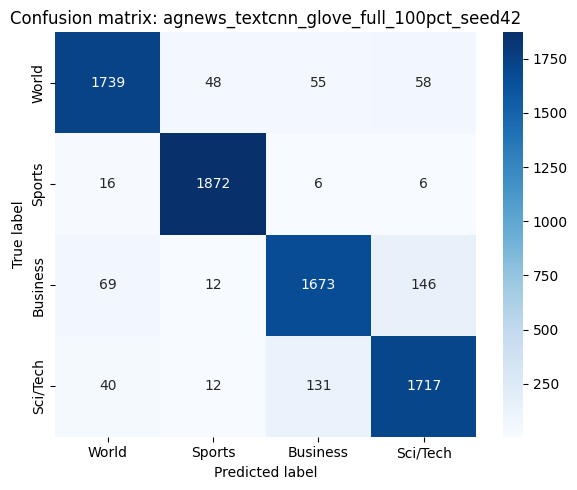

Saved: textcnn_short_context_best_confusion_matrix.png


In [ ]:
# Plot confusion matrix for the best short-context run

best_row = short_context_df.sort_values("test_accuracy", ascending=False).iloc[0]
best_run_name = best_row["run_name"]

with open("textcnn_short_context_results.pkl", "rb") as f:
    full_results = pickle.load(f)

cm = full_results[best_run_name]["confusion_matrix"]

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(f"Confusion matrix: {best_run_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

file_name = "textcnn_short_context_best_confusion_matrix.png"
plt.savefig(file_name, dpi=200)
plt.show()

print("Saved:", file_name)

In [ ]:
# Load saved results if the runtime was restarted

import pandas as pd

short_context_df = pd.read_csv("textcnn_short_context_results.csv")

print("Loaded short_context_df")
print("Rows:", len(short_context_df))


Loaded short_context_df
Rows: 20


In [ ]:
# Check that all short-context runs are in the table

print("Rows:", len(short_context_df))
print("Data sizes:", sorted(short_context_df["data_size"].unique()))
print("Word budgets:", sorted(short_context_df["word_budget"].astype(str).unique()))
print("Methods:", sorted(short_context_df["context_method"].unique()))

expected_rows = 2 + (2 * 3 * 4)

if len(short_context_df) == expected_rows:
    print("All 26 short-context runs are present")
else:
    print("Missing runs - expected", expected_rows, "rows")

print("\nRuns per data size, word budget, and method:")

check_counts = short_context_df.groupby(
    ["data_size", "word_budget", "context_method"]
).size()

print(check_counts)

Rows: 20
Data sizes: ['100%', '50%']
Word budgets: ['16', '20', '52', 'full']
Methods: ['first_n', 'full', 'random_n', 'salient_n']
Missing runs - expected 26 rows

Runs per data size, word budget, and method:
data_size  word_budget  context_method
100%       16           first_n           1
                        random_n          1
                        salient_n         1
           20           first_n           1
                        random_n          1
                        salient_n         1
           52           first_n           1
                        random_n          1
                        salient_n         1
           full         full              1
50%        16           first_n           1
                        random_n          1
                        salient_n         1
           20           first_n           1
                        random_n          1
                        salient_n         1
           52           first_n           1
   

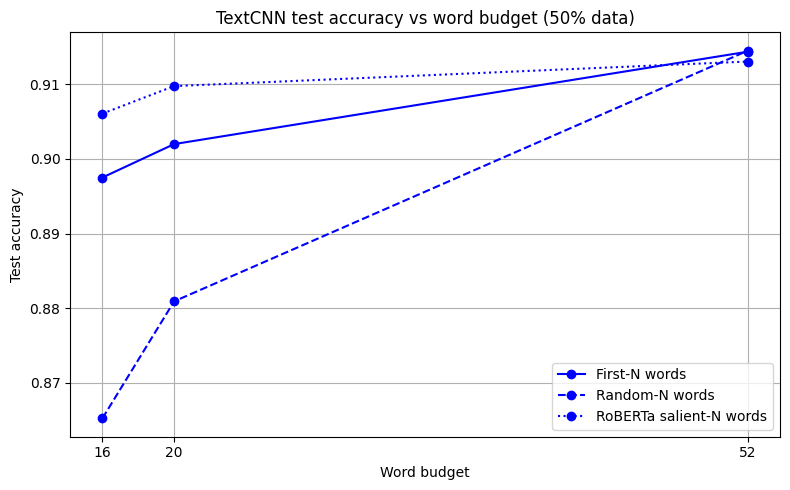

Saved: textcnn_short_context_accuracy_50pct.png


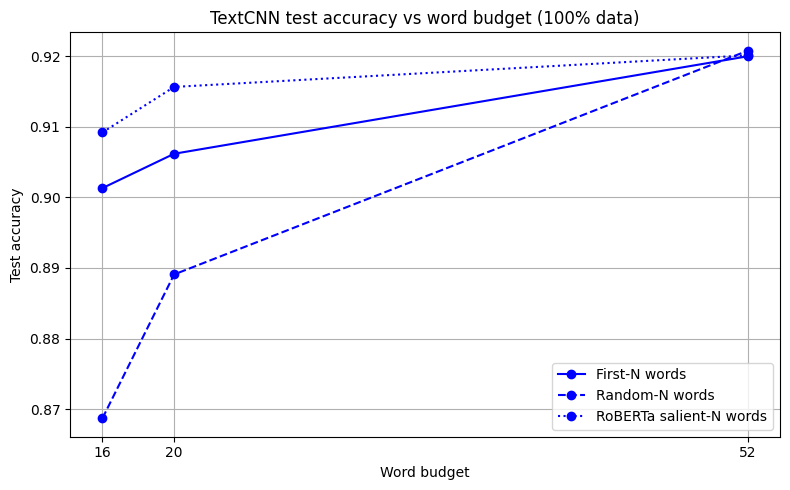

Saved: textcnn_short_context_accuracy_100pct.png


In [ ]:
# Plot test accuracy against word budget

plot_methods = ["first_n", "random_n", "salient_n"]
data_order = ["50%", "100%"]

line_styles = {
    "first_n": "-",
    "random_n": "--",
    "tfidf_n": "-.",
    "salient_n": ":"
}

labels = {
    "first_n": "First-N words",
    "random_n": "Random-N words",
    "tfidf_n": "TF-IDF-N words",
    "salient_n": "RoBERTa salient-N words"
}

for data_size in data_order:
    plot_df = short_context_df[
        (short_context_df["data_size"] == data_size) &
        (short_context_df["context_method"] != "full")
    ].copy()

    plot_df["word_budget"] = plot_df["word_budget"].astype(int)

    plt.figure(figsize=(8, 5))

    for method in plot_methods:
        method_df = plot_df[
            plot_df["context_method"] == method
        ].sort_values("word_budget")

        plt.plot(
            method_df["word_budget"],
            method_df["test_accuracy"],
            marker="o",
            linestyle=line_styles[method],
            color="blue",
            label=labels[method]
        )

    plt.title(f"TextCNN test accuracy vs word budget ({data_size} data)")
    plt.xlabel("Word budget")
    plt.ylabel("Test accuracy")
    plt.xticks(WORD_BUDGETS)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    file_name = f"textcnn_short_context_accuracy_{data_size.replace('%', 'pct')}.png"
    plt.savefig(file_name, dpi=200)
    plt.show()

    print("Saved:", file_name)

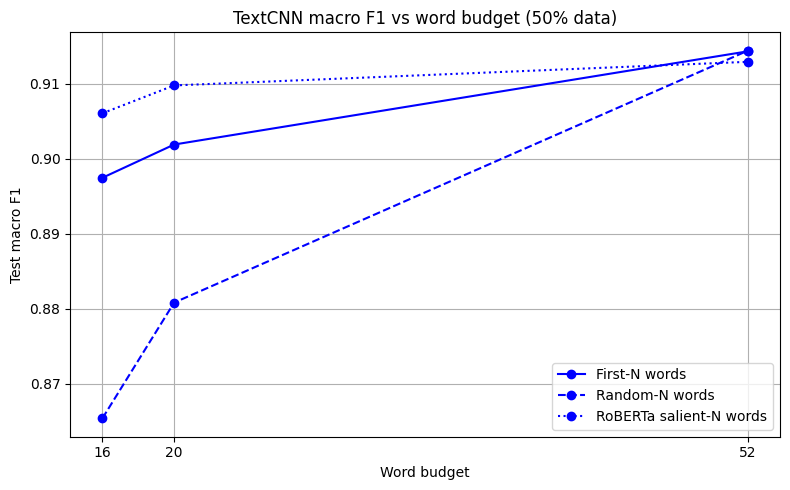

Saved: textcnn_short_context_macro_f1_50pct.png


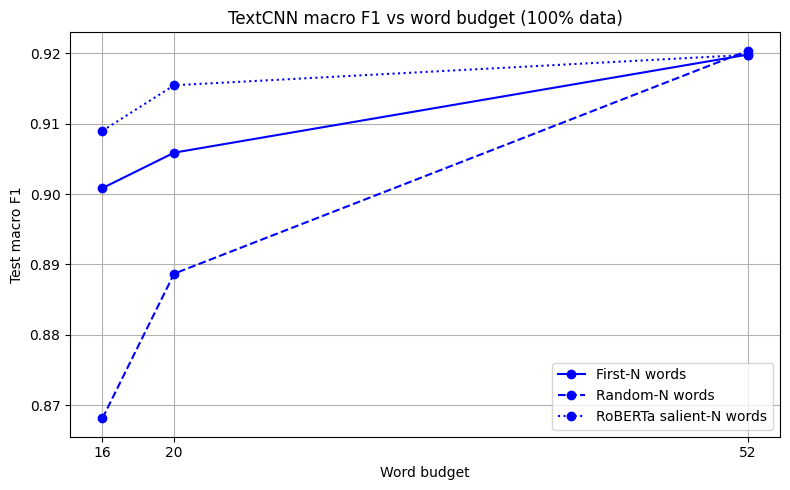

Saved: textcnn_short_context_macro_f1_100pct.png


In [ ]:
# Plot macro F1 against word budget

plot_methods = ["first_n", "random_n", "salient_n"]
data_order = ["50%", "100%"]

line_styles = {
    "first_n": "-",
    "random_n": "--",
    "tfidf_n": "-.",
    "salient_n": ":"
}

labels = {
    "first_n": "First-N words",
    "random_n": "Random-N words",
    "tfidf_n": "TF-IDF-N words",
    "salient_n": "RoBERTa salient-N words"
}

for data_size in data_order:
    plot_df = short_context_df[
        (short_context_df["data_size"] == data_size) &
        (short_context_df["context_method"] != "full")
    ].copy()

    plot_df["word_budget"] = plot_df["word_budget"].astype(int)

    plt.figure(figsize=(8, 5))

    for method in plot_methods:
        method_df = plot_df[
            plot_df["context_method"] == method
        ].sort_values("word_budget")

        plt.plot(
            method_df["word_budget"],
            method_df["test_macro_f1"],
            marker="o",
            linestyle=line_styles[method],
            color="blue",
            label=labels[method]
        )

    plt.title(f"TextCNN macro F1 vs word budget ({data_size} data)")
    plt.xlabel("Word budget")
    plt.ylabel("Test macro F1")
    plt.xticks(WORD_BUDGETS)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    file_name = f"textcnn_short_context_macro_f1_{data_size.replace('%', 'pct')}.png"
    plt.savefig(file_name, dpi=200)
    plt.show()

    print("Saved:", file_name)

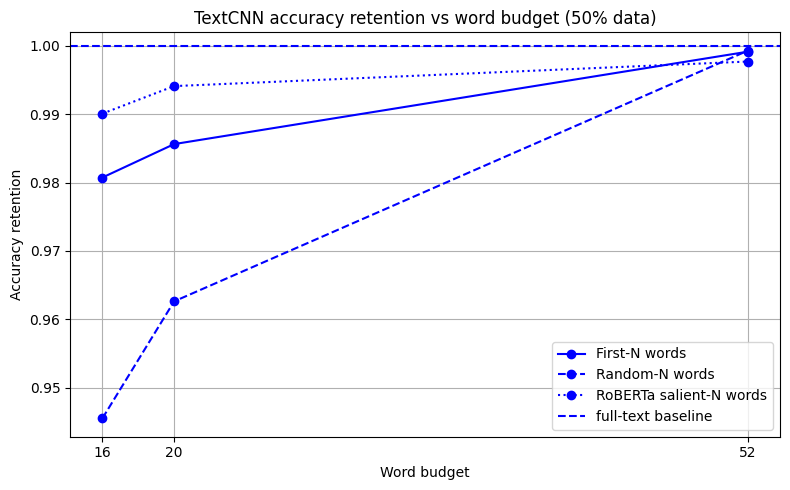

Saved: textcnn_short_context_accuracy_retention_50pct.png


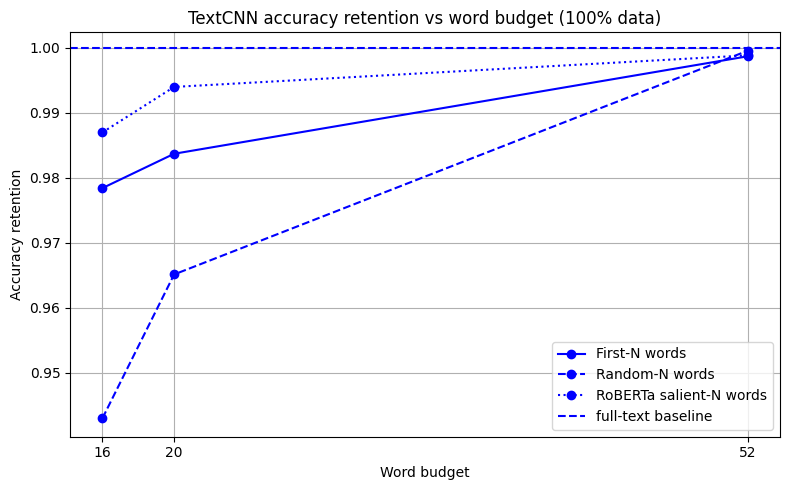

Saved: textcnn_short_context_accuracy_retention_100pct.png


In [ ]:
# Plot accuracy retention compared with the full-text baseline

plot_methods = ["first_n", "random_n", "salient_n"]
data_order = ["50%", "100%"]

line_styles = {
    "first_n": "-",
    "random_n": "--",
    "tfidf_n": "-.",
    "salient_n": ":"
}

labels = {
    "first_n": "First-N words",
    "random_n": "Random-N words",
    "tfidf_n": "TF-IDF-N words",
    "salient_n": "RoBERTa salient-N words"
}

for data_size in data_order:
    plot_df = short_context_df[
        (short_context_df["data_size"] == data_size) &
        (short_context_df["context_method"] != "full")
    ].copy()

    plot_df["word_budget"] = plot_df["word_budget"].astype(int)

    plt.figure(figsize=(8, 5))

    for method in plot_methods:
        method_df = plot_df[
            plot_df["context_method"] == method
        ].sort_values("word_budget")

        plt.plot(
            method_df["word_budget"],
            method_df["accuracy_retention_vs_full_context"],
            marker="o",
            linestyle=line_styles[method],
            color="blue",
            label=labels[method]
        )

    plt.axhline(
        1.0,
        linestyle="--",
        color="blue",
        label="full-text baseline"
    )

    plt.title(f"TextCNN accuracy retention vs word budget ({data_size} data)")
    plt.xlabel("Word budget")
    plt.ylabel("Accuracy retention")
    plt.xticks(WORD_BUDGETS)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    file_name = f"textcnn_short_context_accuracy_retention_{data_size.replace('%', 'pct')}.png"
    plt.savefig(file_name, dpi=200)
    plt.show()

    print("Saved:", file_name)

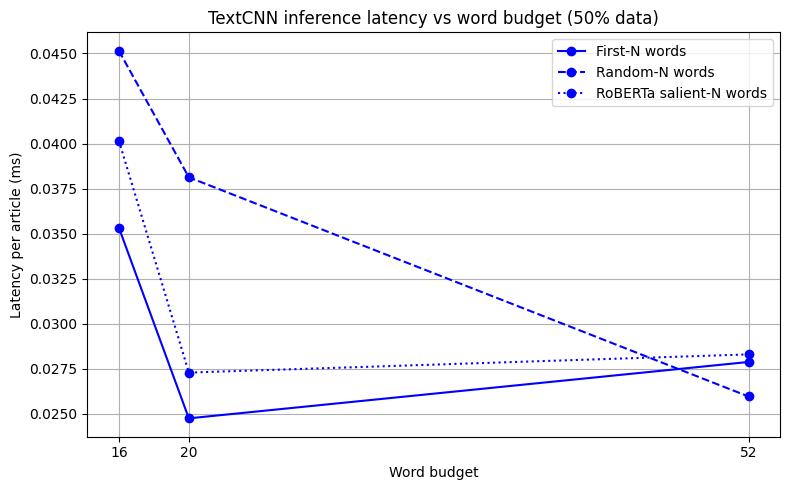

Saved: textcnn_short_context_latency_50pct.png


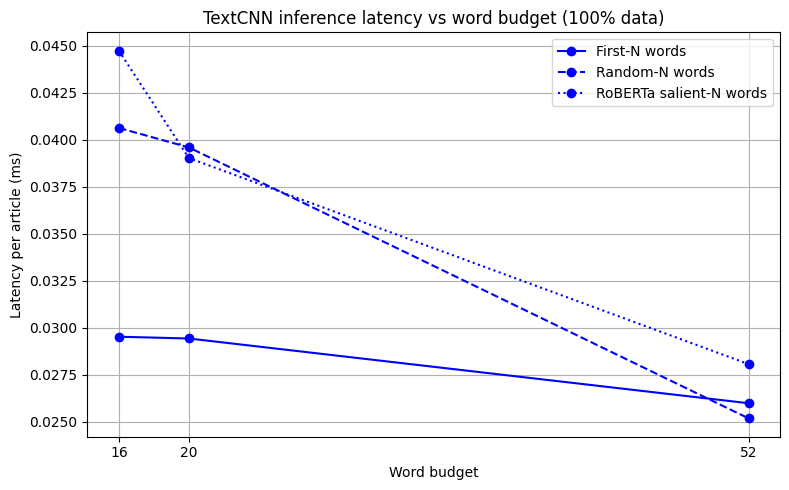

Saved: textcnn_short_context_latency_100pct.png


In [ ]:
# Plot inference latency for each word budget

plot_methods = ["first_n", "random_n", "salient_n"]
data_order = ["50%", "100%"]

line_styles = {
    "first_n": "-",
    "random_n": "--",
    "tfidf_n": "-.",
    "salient_n": ":"
}

labels = {
    "first_n": "First-N words",
    "random_n": "Random-N words",
    "tfidf_n": "TF-IDF-N words",
    "salient_n": "RoBERTa salient-N words"
}

for data_size in data_order:
    plot_df = short_context_df[
        (short_context_df["data_size"] == data_size) &
        (short_context_df["context_method"] != "full")
    ].copy()

    plot_df["word_budget"] = plot_df["word_budget"].astype(int)

    plt.figure(figsize=(8, 5))

    for method in plot_methods:
        method_df = plot_df[
            plot_df["context_method"] == method
        ].sort_values("word_budget")

        plt.plot(
            method_df["word_budget"],
            method_df["latency_per_article_ms"],
            marker="o",
            linestyle=line_styles[method],
            color="blue",
            label=labels[method]
        )

    plt.title(f"TextCNN inference latency vs word budget ({data_size} data)")
    plt.xlabel("Word budget")
    plt.ylabel("Latency per article (ms)")
    plt.xticks(WORD_BUDGETS)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    file_name = f"textcnn_short_context_latency_{data_size.replace('%', 'pct')}.png"
    plt.savefig(file_name, dpi=200)
    plt.show()

    print("Saved:", file_name)

In [ ]:
# Show strongest short-context runs by test accuracy

best_runs = short_context_df.sort_values(
    "test_accuracy",
    ascending=False
)[
    [
        "run_name",
        "data_size",
        "word_budget",
        "context_method",
        "test_accuracy",
        "test_macro_f1",
        "accuracy_retention_vs_full_context",
        "macro_f1_retention_vs_full_context",
        "accuracy_drop_vs_full_context",
        "training_time_s",
        "latency_per_article_ms",
        "preprocess_time_s",
        "weights_file"
    ]
].head(10)

best_runs

,run_name,data_size,word_budget,context_method,test_accuracy,test_macro_f1,accuracy_retention_vs_full_context,macro_f1_retention_vs_full_context,accuracy_drop_vs_full_context,training_time_s,latency_per_article_ms,preprocess_time_s,weights_file
10,agnews_textcnn_glove_full_100pct_seed42,100%,full,full,0.921184,0.921006,1.000000,1.000000,0.000000,373.137100,0.026995,0.000003,agnews_textcnn_glove_full_100pct_seed42.pth
18,agnews_textcnn_glove_random52_100pct_seed42,100%,52,random_n,0.920789,0.920390,0.999571,0.999331,0.000395,370.553268,0.025185,1.225461,agnews_textcnn_glove_random52_100pct_seed42.pth
19,agnews_textcnn_glove_salient52_100pct_seed42,100%,52,salient_n,0.920132,0.919802,0.998857,0.998693,0.001053,369.958746,0.028070,0.793230,agnews_textcnn_glove_salient52_100pct_seed42.pth
17,agnews_textcnn_glove_first52_100pct_seed42,100%,52,first_n,0.920000,0.919836,0.998714,0.998730,0.001184,372.331592,0.025989,0.819582,agnews_textcnn_glove_first52_100pct_seed42.pth
16,agnews_textcnn_glove_salient20_100pct_seed42,100%,20,salient_n,0.915658,0.915478,0.994001,0.993998,0.005526,372.341655,0.039024,2.287192,agnews_textcnn_glove_salient20_100pct_seed42.pth
0,agnews_textcnn_glove_full_50pct_seed42,50%,full,full,0.915132,0.915070,1.000000,1.000000,0.000000,194.968729,0.046466,0.000004,agnews_textcnn_glove_full_50pct_seed42.pth
8,agnews_textcnn_glove_random52_50pct_seed42,50%,52,random_n,0.914474,0.914406,0.999281,0.999274,0.000658,186.274697,0.025949,0.567061,agnews_textcnn_glove_random52_50pct_seed42.pth
7,agnews_textcnn_glove_first52_50pct_seed42,50%,52,first_n,0.914342,0.914323,0.999137,0.999184,0.000789,184.540778,0.027866,0.286202,agnews_textcnn_glove_first52_50pct_seed42.pth
9,agnews_textcnn_glove_salient52_50pct_seed42,50%,52,salient_n,0.913026,0.912926,0.997699,0.997657,0.002105,187.355973,0.028286,0.380750,agnews_textcnn_glove_salient52_50pct_seed42.pth
6,agnews_textcnn_glove_salient20_50pct_seed42,50%,20,salient_n,0.909737,0.909779,0.994105,0.994218,0.005395,184.647961,0.027276,1.427424,agnews_textcnn_glove_salient20_50pct_seed42.pth


In [ ]:
# Check Business and Sci/Tech confusion across short-context runs

if not os.path.exists("textcnn_short_context_results.pkl"):
    print("Missing textcnn_short_context_results.pkl")
else:
    with open("textcnn_short_context_results.pkl", "rb") as f:
        full_results = pickle.load(f)

    confusion_rows = []

    for run_name, result in full_results.items():
        cm = result["confusion_matrix"]

        # AG News labels: 2 = Business, 3 = Sci/Tech
        business_as_scitech = cm[2, 3]
        scitech_as_business = cm[3, 2]

        business_scitech_total = cm[2].sum() + cm[3].sum()
        confusion_total = business_as_scitech + scitech_as_business

        confusion_rows.append({
            "run_name": run_name,
            "data_size": result["data_size"],
            "word_budget": result["word_budget"],
            "context_method": result["context_method"],
            "business_as_scitech": business_as_scitech,
            "scitech_as_business": scitech_as_business,
            "business_scitech_confusion_total": confusion_total,
            "business_scitech_confusion_rate": confusion_total / business_scitech_total
        })

    business_scitech_df = pd.DataFrame(confusion_rows)

    method_order = {
        "full": 0,
        "first_n": 1,
        "random_n": 2,
        "tfidf_n": 3,
        "salient_n": 4
    }

    business_scitech_df["method_order"] = business_scitech_df["context_method"].map(method_order)
    business_scitech_df["word_budget_sort"] = business_scitech_df["word_budget"].apply(
        lambda x: 0 if x == "full" else int(x)
    )

    business_scitech_df = business_scitech_df.sort_values(
        ["data_size", "word_budget_sort", "method_order"]
    ).drop(columns=["method_order", "word_budget_sort"]).reset_index(drop=True)

    print("Business/SciTech confusion rows:", len(business_scitech_df))
    display(business_scitech_df)

Business/SciTech confusion rows: 20


,run_name,data_size,word_budget,context_method,business_as_scitech,scitech_as_business,business_scitech_confusion_total,business_scitech_confusion_rate
0,agnews_textcnn_glove_full_100pct_seed42,100%,full,full,146,131,277,0.072895
1,agnews_textcnn_glove_first16_100pct_seed42,100%,16,first_n,156,154,310,0.081579
2,agnews_textcnn_glove_random16_100pct_seed42,100%,16,random_n,169,203,372,0.097895
3,agnews_textcnn_glove_salient16_100pct_seed42,100%,16,salient_n,175,119,294,0.077368
4,agnews_textcnn_glove_first20_100pct_seed42,100%,20,first_n,142,151,293,0.077105
5,agnews_textcnn_glove_random20_100pct_seed42,100%,20,random_n,206,146,352,0.092632
6,agnews_textcnn_glove_salient20_100pct_seed42,100%,20,salient_n,165,112,277,0.072895
7,agnews_textcnn_glove_first52_100pct_seed42,100%,52,first_n,147,133,280,0.073684
8,agnews_textcnn_glove_random52_100pct_seed42,100%,52,random_n,159,106,265,0.069737
9,agnews_textcnn_glove_salient52_100pct_seed42,100%,52,salient_n,150,111,261,0.068684


In [ ]:
# Check final saved files

import os

for file in os.listdir():
    print(file)

.config
agnews_textcnn_glove_first16_100pct_seed42.pth
textcnn_short_context_accuracy_retention_50pct.png
agnews_textcnn_glove_first20_100pct_seed42.pth
agnews_textcnn_glove_salient16_50pct_seed42.pth
agnews_textcnn_glove_random16_50pct_seed42.pth
agnews_textcnn_glove_salient20_100pct_seed42.pth
agnews_textcnn_glove_full_50pct_seed42.pth
agnews_textcnn_glove_salient20_50pct_seed42.pth
agnews_textcnn_glove_random52_50pct_seed42.pth
textcnn_short_context_latency_50pct.png
agnews_textcnn_glove_first52_100pct_seed42.pth
agnews_textcnn_glove_salient52_100pct_seed42.pth
agnews_textcnn_glove_first16_50pct_seed42.pth
textcnn_short_context_macro_f1_50pct.png
textcnn_short_context_latency_100pct.png
agnews_textcnn_glove_random52_100pct_seed42.pth
agnews_textcnn_glove_salient52_50pct_seed42.pth
textcnn_short_context_accuracy_100pct.png
agnews_textcnn_glove_first20_50pct_seed42.pth
glove.6B.zip
agnews_textcnn_glove_random16_100pct_seed42.pth
textcnn_short_context_results.csv
agnews_textcnn_glove_r

In [ ]:
from google.colab import files

files.download("textcnn_short_context_results.csv")
files.download("textcnn_short_context_results.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Saved Model Weights

The trained TextCNN model ShortContext-weights are stored here:

[TextCNN AG News weights](https://drive.google.com/drive/folders/1APBRibyJWECb34Xy4TX0ZbIXE90SKB_H?usp=drive_link)